In [1]:
import cv2
import matplotlib.pyplot as plt
import time

In [477]:
import cv2
import numpy as np

video_path = "/workspace/test_videos/cam2_1754411477.mp4"
cap = cv2.VideoCapture(video_path)

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Optional: resize to consistent dimensions
    # frame = cv2.resize(frame, (224, 224))

    # Convert BGR → RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to float32 and normalize [0,1]
    frame = frame.astype(np.float32) / 255.0

    frames.append(frame)

cap.release()

# Stack into a 4D NumPy tensor
video_tensor = np.stack(frames)  # shape: (num_frames, H, W, 3)

print("Video tensor shape:", video_tensor.shape)

masked_video_path = "/workspace/test_results/cam2_1754411798.av"
cap = cv2.VideoCapture(video_path)

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Optional: resize to consistent dimensions
    # frame = cv2.resize(frame, (224, 224))

    # Convert BGR → RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to float32 and normalize [0,1]
    frame = frame.astype(np.float32) / 255.0

    frames.append(frame)

cap.release()

# Stack into a 4D NumPy tensor
masked_video_tensor = np.stack(frames)  # shape: (num_frames, H, W, 3)

print("Video tensor shape:", video_tensor.shape)



Video tensor shape: (300, 480, 640, 3)
Video tensor shape: (300, 480, 640, 3)


In [561]:
path = "/workspace/test_results/cam1_1754411337.npy"
segmened_video2 = np.load(path)

In [4]:
import cv2
import numpy as np

def to_gray_u8(img):
    # If 3/4-channel -> convert to gray
    if img.ndim == 3:
        if img.shape[2] == 3:
            g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        elif img.shape[2] == 4:
            g = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        else:
            raise ValueError(f"Unexpected channel count: {img.shape[2]}")
    else:
        g = img

    # Ensure uint8 range
    if g.dtype != np.uint8:
        g = np.clip(g, 0, 255)
        if g.max() <= 1.0:  # looks like 0..1 float
            g = (g * 255.0).astype(np.uint8)
        else:
            g = g.astype(np.uint8)
    return g

def estimate_rotation_R(prev_img, curr_img, K):
    prev_gray = to_gray_u8(prev_img)
    gray = to_gray_u8(curr_img)

    mask = np.zeros(gray.shape, np.uint8)
    mask[int(0.2*h):int(0.8*h), int(0.2*w):int(0.8*w)] = 255

    
    orb = cv2.ORB_create(nfeatures=2000)
    kp1, des1 = orb.detectAndCompute(prev_gray, mask)
    kp2, des2 = orb.detectAndCompute(gray, mask)
    
    if des1 is None or des2 is None or len(kp1) < 8 or len(kp2) < 8:
        raise RuntimeError("Not enough ORB features/descriptors.")

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    if len(matches) < 8:
        raise RuntimeError("Not enough matches after ORB.")

    matches = sorted(matches, key=lambda m: m.distance)[:800]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])  # prev
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])  # curr

    F, maskF = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 0.7, 0.99)
    if F is None:
        raise RuntimeError("findFundamentalMat failed.")
    pts1 = pts1[maskF.ravel() == 1]
    pts2 = pts2[maskF.ravel() == 1]
    if len(pts1) < 8:
        raise RuntimeError("Too few inliers after F RANSAC.")

    E, maskE = cv2.findEssentialMat(pts2, pts1, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    if E is None:
        raise RuntimeError("findEssentialMat failed.")
    _, R, t, maskPose = cv2.recoverPose(E, pts2, pts1, K)
    return R  # 3x3 rotation from prev -> curr

In [484]:
gray_tensor = np.stack([
    cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    for frame in video_tensor
])

In [6]:
gray_frame = cv2.cvtColor(video_tensor[200], cv2.COLOR_RGB2GRAY)
gray_frame_last = cv2.cvtColor(video_tensor[196], cv2.COLOR_RGB2GRAY)

w = 640
width = w
h = 480
height = h
fov_deg = 120
fov_rad = np.deg2rad(fov_deg)

fx = width / (2 * np.tan(fov_rad / 2))  # ~185.37 px
fy = fx  # Assuming square pixels and similar vertical FOV

cx = width / 2   # 320
cy = height / 2  # 240

K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
])


import numpy as np

def r2ypr_zyx(R):
    # clamp to avoid NaNs from tiny numerical errors
    sy = -R[2,0]
    sy = np.clip(sy, -1.0, 1.0)
    pitch = np.arcsin(sy)
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    return yaw, pitch, roll  # in radians



R = estimate_rotation_R(gray_frame_last, gray_frame, K)

r2ypr_zyx(R)

(-0.03617051144822145, -0.017990014316906312, -0.034677861637435387)

In [7]:
def r2q(R):
    # (w, x, y, z)
    K = np.array([
        [R[0,0]-R[1,1]-R[2,2], 0, 0, 0],
        [R[1,0]+R[0,1], R[1,1]-R[0,0]-R[2,2], 0, 0],
        [R[2,0]+R[0,2], R[2,1]+R[1,2], R[2,2]-R[0,0]-R[1,1], 0],
        [R[1,2]-R[2,1], R[2,0]-R[0,2], R[0,1]-R[1,0], R[0,0]+R[1,1]+R[2,2]]
    ]) / 3.0
    w, V = np.linalg.eigh(K)
    q = V[:, np.argmax(w)]
    q = np.array([q[3], q[0], q[1], q[2]])  # to (w,x,y,z)
    return q/np.linalg.norm(q)

def q_slerp(q0, q1, alpha):
    # alpha in [0,1]
    dot = np.dot(q0, q1)
    if dot < 0: q1, dot = -q1, -dot
    if dot > 0.9995:
        q = q0 + alpha*(q1-q0)
        return q/np.linalg.norm(q)
    theta = np.arccos(np.clip(dot, -1, 1))
    s0 = np.sin((1-alpha)*theta)/np.sin(theta)
    s1 = np.sin(alpha*theta)/np.sin(theta)
    return s0*q0 + s1*q1

    
alpha = 0  # smoothing (increase for more smoothing)
q_global = np.array([1,0,0,0])
q_global_tensor = np.zeros((4, 299))

time0 = time.time()

for i in range(299):
    gray_frame = gray_tensor[i +1]
    gray_frame_last = gray_tensor[i]
    R_step = estimate_rotation_R(gray_frame_last, gray_frame, K)
    q_step = r2q(R_step)
    q_global = q_slerp(q_global, q_step*q_global, alpha)  # compose then smooth
    q_global_tensor[:, i] = q_global
print(f"total time = {time.time() - time0}")

RuntimeError: Too few inliers after F RANSAC.

In [10]:
q_global_tensor

array([[1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

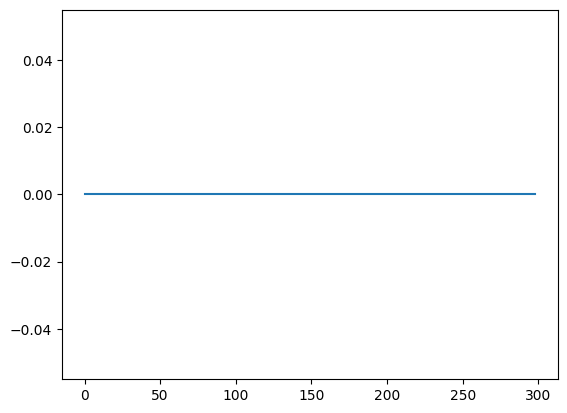

In [11]:
plt.plot(q_global_tensor[2])

In [7]:
import numpy as np, time

def r2ypr_zyx(R):
    """
    Extract yaw (Z), pitch (Y), roll (X) from rotation matrix using ZYX order.
    Returns radians: (yaw, pitch, roll).
    """
    # clamp to handle tiny numeric errors
    sy = -R[2,0]
    sy = np.clip(sy, -1.0, 1.0)
    pitch = np.arcsin(sy)
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    return yaw, pitch, roll

# ---- no smoothing, just Euler updates ----
N = gray_tensor.shape[0] - 1  # because we use i and i+1
R_global = np.eye(3)

ypr_global = np.zeros((3, N))      # radians: rows = [yaw, pitch, roll]
ypr_step   = np.zeros((3, N))      # optional: per-frame incremental angles

t0 = time.time()
for i in range(N):
    gray_frame_last = gray_tensor[i]
    gray_frame      = gray_tensor[i+1]

    # relative rotation from frame i -> i+1
    R_step = estimate_rotation_R(gray_frame_last, gray_frame, K)

    # (optional) per-step angles (incremental)
    ypr_step[:, i] = r2ypr_zyx(R_step)

    # compose to keep a running/global orientation
    R_global = R_step @ R_global

    # global angles after this update
    ypr_global[:, i] = r2ypr_zyx(R_global)

print(f"total time = {time.time() - t0:.3f}s")

# If you want degrees:
ypr_global_deg = np.degrees(ypr_global)
ypr_step_deg   = np.degrees(ypr_step)


RuntimeError: Too few inliers after F RANSAC.

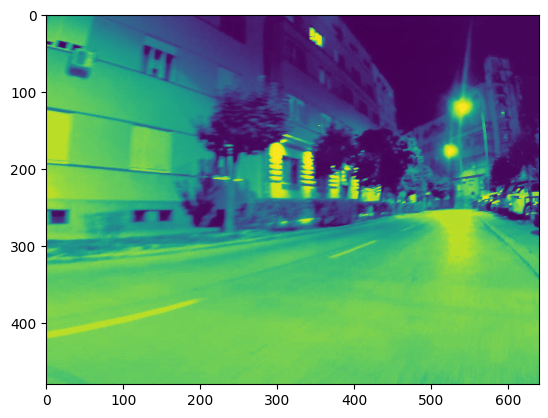

In [8]:
plt.imshow(gray_tensor[299])

mask = np.equal(segmened_video[60], 0)
plt.imshow()

In [3]:
from __future__ import annotations
import numpy as np
import cv2
from dataclasses import dataclass

@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S

class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg
        
        S = grid.scaling_matrix()
        self.S = S
        

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M

        
        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)
    
        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)
    
        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)
    
        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src




In [4]:
import numpy as np
import cv2
import os

# Assumes BEVProjector and BEVGrid are already defined somewhere above
# (or imported from your module)

def _build_intrinsics(W, H, K0=None, K0_size=None, fx=1100.0, fy=None):
    if K0 is not None and K0_size is not None:
        W0, H0 = K0_size
        sx, sy = W / float(W0), H / float(H0)
        return np.array([
            [K0[0,0]*sx, 0.0,           K0[0,2]*sx],
            [0.0,        K0[1,1]*sy,    K0[1,2]*sy],
            [0.0,        0.0,           1.0]
        ], dtype=np.float64)
    
    if fy is None:
        fy = fx
    cx, cy = W / 2.0, H / 2.0
    return np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)

def video_to_bev_tensor(
    video_tensor,
    segmented_video,
    n_frames=None,
    *,
    height_m=1.4,
    pitch_deg_down=6.0,
    roll_deg=0.0,
    yaw_deg=0.0,
    K0=None,
    K0_size=None,
    fx=1100.0,
    fy=None,
    meters_per_pixel=0.10,
    forward_range=(0.5, 40.0),
    lateral_range=(-8.0, 8.0),
    debug=False
):
    N_all = min(len(video_tensor), len(segmented_video))
    N = N_all if n_frames is None else min(n_frames, N_all)

    H, W = segmented_video[0].shape[:2]
    K = _build_intrinsics(W, H, K0=K0, K0_size=K0_size, fx=fx, fy=fy)

    roll = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)
    yaw = np.deg2rad(yaw_deg)

    projector = BEVProjector().set_intrinsics(K).set_pose(
        height_m=height_m,
        roll=roll,
        pitch=pitch,
        yaw=yaw
    )

    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range
    )

    W_out, H_out = grid.size
    bev_tensor = np.zeros((H_out, W_out, N), dtype=np.uint8)

    for i in range(N):
        mask01 = (segmented_video[i] == 0).astype(np.uint8)
        bev = projector.warp_calibrated(mask01=mask01, grid=grid)
        bev_tensor[:, :, i] = bev

        if debug and (i == 0 or (i + 1) == N):
            H_pg, S = projector.H_pg, grid.scaling_matrix()
            A = H_pg @ S
            dst = np.array([[0,0,1],[W_out-1,0,1],[W_out-1,H_out-1,1],[0,H_out-1,1]], dtype=np.float64).T
            img_corners = (A @ dst); img_corners = (img_corners[:2]/img_corners[2]).T
            print(f"[DEBUG frame {i}] BEV corners -> image:\n", img_corners)
            print(f"[DEBUG frame {i}] bev.sum() = {bev.sum()}")

    return bev_tensor, projector, grid


def npy_to_bev_tensor(
    path,
    n_frames=None,
    *,
    pitch_deg_down=6.0,
    height_m=1.4,
    fx=1100.0,
    fy=530,
    meters_per_pixel=0.10,
    forward_range=(0.5, 40.0),
    lateral_range=(-8.0, 8.0),
    debug=False
):
    """
    Convenience wrapper:
    Loads `.npy` path with segmented labels (cam1_*.npy),
    assumes road label is 0,
    and returns BEV-projected tensor.
    """
    assert os.path.exists(path), f"File not found: {path}"
    segmented_video = np.load(path)

    # Dummy grayscale frames for compatibility (same shape, unused)
    H, W = segmented_video[0].shape
    dummy_video = np.stack([
        np.zeros((H, W, 3), dtype=np.uint8)
        for _ in range(len(segmented_video))
    ])

    return video_to_bev_tensor(
        video_tensor=dummy_video,
        segmented_video=segmented_video,
        n_frames=n_frames,
        height_m=height_m,
        pitch_deg_down=pitch_deg_down,
        fx=fx,
        fy=fy,
        meters_per_pixel=meters_per_pixel,
        forward_range=forward_range,
        lateral_range=lateral_range,
        debug=debug
    )


# Process directly from file path:

path = "/workspace/test_results/cam1_1754411337.npy"
bev_tensor1, projector1, grid1 = npy_to_bev_tensor(
    path, 
    n_frames=300, 
    debug=True,     
    pitch_deg_down=0.0,
    height_m=1,
    fx=300,
    fy=int(530/380*200),
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

path = "/workspace/test_results/cam2_1754411337.npy"
bev_tensor2, projector2, grid2 = npy_to_bev_tensor(
    path, 
    n_frames=300, 
    debug=True,     
    pitch_deg_down=0.0,
    height_m=1,
    fx=380.0,
    fy=530,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)
bev_cal_tensor = 0
# Shape: (H_bev, W_bev, N)



[DEBUG frame 0] BEV corners -> image:
 [[  120.           249.26666667]
 [  518.           249.26666667]
 [10220.           703.33333333]
 [-9680.           703.33333333]]
[DEBUG frame 0] bev.sum() = 847875
[DEBUG frame 299] BEV corners -> image:
 [[  120.           249.26666667]
 [  518.           249.26666667]
 [10220.           703.33333333]
 [-9680.           703.33333333]]
[DEBUG frame 299] bev.sum() = 1559580
[DEBUG frame 0] BEV corners -> image:
 [[    66.66666667    257.66666667]
 [   570.8           257.66666667]
 [ 12860.           1123.33333333]
 [-12346.66666667   1123.33333333]]
[DEBUG frame 0] bev.sum() = 255510
[DEBUG frame 299] BEV corners -> image:
 [[    66.66666667    257.66666667]
 [   570.8           257.66666667]
 [ 12860.           1123.33333333]
 [-12346.66666667   1123.33333333]]
[DEBUG frame 299] bev.sum() = 613785


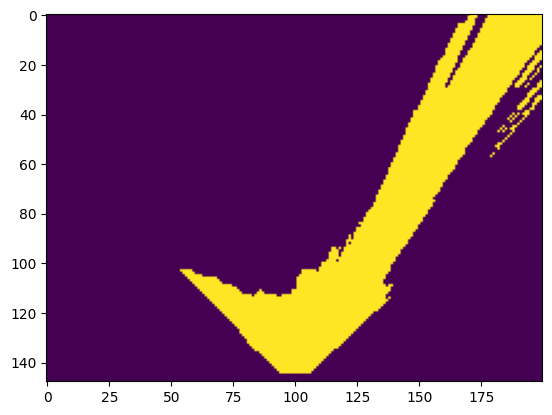

In [700]:
n = 80
plt.imshow(bev_tensor1[:, :, n])

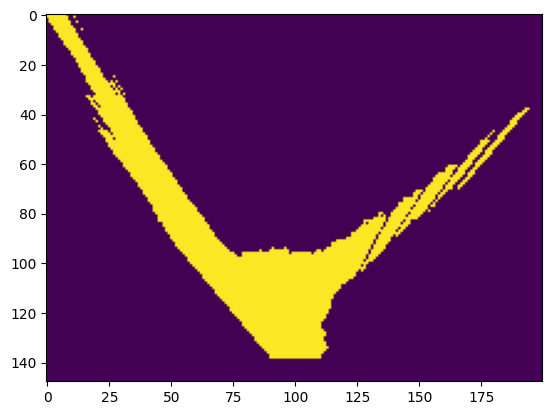

In [701]:
plt.imshow(bev_tensor2[:, :, n])

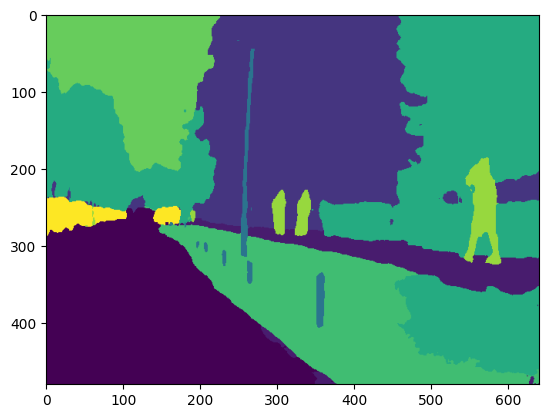

In [676]:
plt.imshow(segmened_video[n])

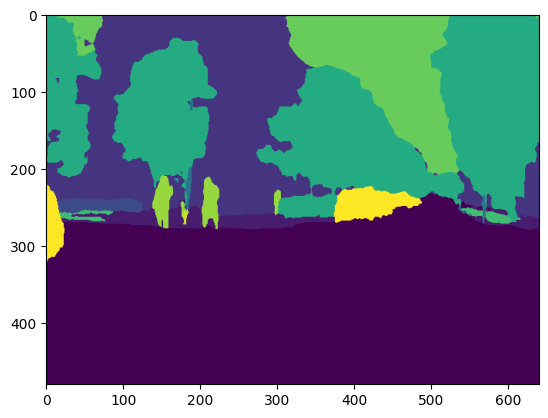

In [686]:
plt.imshow(segmened_video2[n])

In [ ]:
plt.imshow(te)

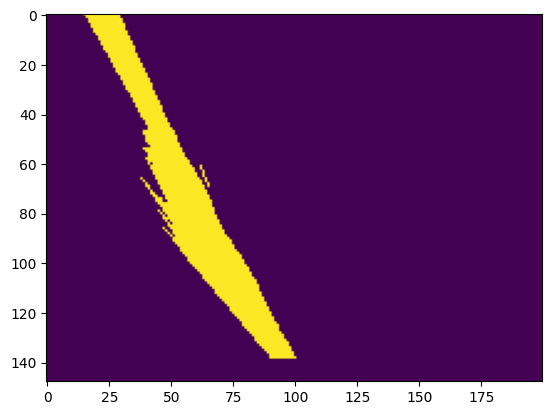

In [559]:
plt.imshow(bev_tensor2[:, :, n])

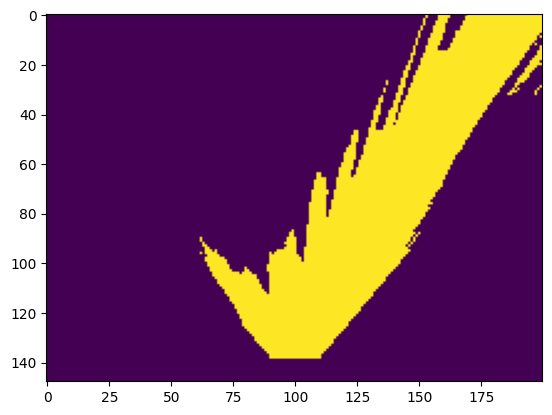

In [558]:
plt.imshow(bev_tensor1[:, :, n])

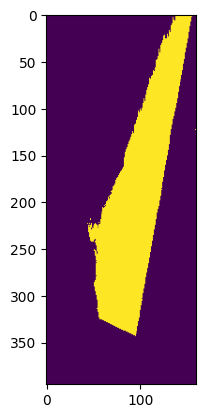

In [324]:
plt.imshow(bev_tensor1[:, :, n])

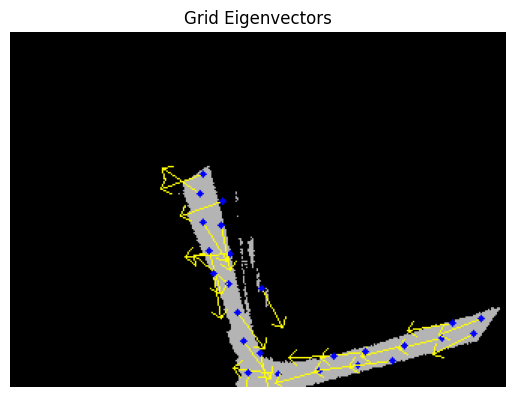

In [813]:
import numpy as np
import cv2
I_global = None
# ----------------------------
# PCA helper
# ----------------------------
def _pca(points_xy):
    mu = points_xy.mean(axis=0)
    X = points_xy - mu
    C = (X.T @ X) / max(len(X), 1)
    evals, evecs = np.linalg.eigh(C)          # ascending
    idx = np.argsort(evals)[::-1]             # descending
    evals = evals[idx]
    v_major = evecs[:, idx][:, 0]
    v_major = v_major / (np.linalg.norm(v_major) + 1e-12)
    return mu, v_major, evals

# ----------------------------
# grid + scoring (keep top N tiles by mass)
# ----------------------------
def _grid_top_tiles(binary_img, grid_rc=(10,10), top_n=40, min_pts=15):
    H, W = binary_img.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)

    I = (binary_img > 0).astype(np.uint8)
    tiles = []
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]
            x0, x1 = xs[gj], xs[gj+1]
            roi = I[y0:y1, x0:x1]
            mass = int(roi.sum())
            if mass <= 0:
                continue
            yy, xx = np.nonzero(roi)
            if len(xx) < min_pts:
                continue
            pts = np.column_stack([xx + x0, yy + y0]).astype(np.float32)

            # per-tile PCA
            mu = pts.mean(axis=0)
            X = pts - mu
            COV = (X.T @ X) / len(pts)
            evals, evecs = np.linalg.eigh(COV)
            v = evecs[:, 1] / (np.linalg.norm(evecs[:, 1]) + 1e-12)  # major dir (2,)

            tiles.append({
                'gi': gi, 'gj': gj,
                'box': (y0, y1, x0, x1),
                'mass': mass,
                'centroid': (float(mu[0]), float(mu[1])),
                'dir': v.astype(np.float32)
            })

    tiles.sort(key=lambda d: d['mass'], reverse=True)
    return tiles[:min(top_n, len(tiles))]

# ----------------------------
# merge touching tiles into groups (8-connected on grid)
# ----------------------------
# --- replace _merge_touching with 4-connected toggle ---
import math

import math
import numpy as np

def _shared_edge_has_fg(I, a, b, ys, xs, border_w=2, min_count=3):
    """Check if two 4-neighbor tiles share foreground along their common edge."""
    gi, gj = a['gi'], a['gj']
    hi, hj = b['gi'], b['gj']
    H, W = I.shape

    if gi == hi and abs(gj - hj) == 1:
        # vertical seam between columns gj and hj
        j_left, j_right = (gj, hj) if gj < hj else (hj, gj)
        y0, y1 = ys[gi], ys[gi+1]
        x_edge = xs[j_right]
        x0 = max(0, x_edge - border_w)
        x1 = min(W, x_edge + border_w)
        band = I[y0:y1, x0:x1]
        return int(band.sum()) >= min_count

    if gj == hj and abs(gi - hi) == 1:
        # horizontal seam between rows gi and hi
        i_top, i_bot = (gi, hi) if gi < hi else (hi, gi)
        x0, x1 = xs[gj], xs[gj+1]
        y_edge = ys[i_bot]
        y0 = max(0, y_edge - border_w)
        y1 = min(H, y_edge + border_w)
        band = I[y0:y1, x0:x1]
        return int(band.sum()) >= min_count

    return False

def _merge_touching(tiles, grid_rc, binary_img, theta_merge_deg=25.0, require_edge_conn=True):
    """
    4-connected merging with orientation gating and (optional) shared-edge foreground check.
    """
    if not tiles:
        return []

    R, C = grid_rc
    H, W = binary_img.shape
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)

    idx_by_cell = {(t['gi'], t['gj']): k for k, t in enumerate(tiles)}
    N = len(tiles)
    seen = np.zeros(N, dtype=bool)
    groups = []

    V = np.stack([t['dir'] for t in tiles], axis=0)  # (N,2)

    def angle_ok(i, j):
        vi, vj = V[i], V[j]
        c = abs(float(np.dot(vi, vj)) / ((np.linalg.norm(vi)+1e-12)*(np.linalg.norm(vj)+1e-12)))
        c = np.clip(c, -1.0, 1.0)
        ang = math.degrees(math.acos(c))
        return ang <= theta_merge_deg

    neigh4 = [(1,0), (-1,0), (0,1), (0,-1)]

    for s in range(N):
        if seen[s]:
            continue
        stack = [s]; seen[s] = True
        comp = [s]
        while stack:
            i = stack.pop()
            gi, gj = tiles[i]['gi'], tiles[i]['gj']
            for di, dj in neigh4:
                ni, nj = gi + di, gj + dj
                j = idx_by_cell.get((ni, nj))
                if j is None or seen[j]:
                    continue
                if not angle_ok(i, j):
                    continue
                if require_edge_conn and not _shared_edge_has_fg(binary_img, tiles[i], tiles[j], ys, xs):
                    continue
                seen[j] = True
                stack.append(j)
                comp.append(j)
        groups.append(comp)
    return groups
# ----------------------------
# extract per-group PCA, centroid, mass
# ----------------------------
def _group_descriptors(binary_img, tiles, groups):
    I = (binary_img > 0).astype(np.uint8)
    desc = []
    for comp in groups:
        # gather all foreground coords within all tiles in this component
        pts = []
        mass_sum = 0
        for idx in comp:
            y0, y1, x0, x1 = tiles[idx]['box']
            roi = I[y0:y1, x0:x1]
            yy, xx = np.nonzero(roi)
            if len(xx):
                pts.append(np.column_stack([xx + x0, yy + y0]))
            mass_sum += tiles[idx]['mass']
        if not pts:
            continue
        P = np.vstack(pts).astype(np.float32)
        mu, v_major, evals = _pca(P)
        desc.append({
            'mass': int(mass_sum),
            'centroid': (float(mu[0]), float(mu[1])),
            'dir': v_major.copy(),
            'evals': evals.copy(),
            'tile_indices': comp
        })
    return desc

# ----------------------------
# fit best global curve through top-F groups
# Parametric cubic by projecting onto a global axis for ordering
# ----------------------------
def _fit_curve(groups_desc, F=12, degree=3, nsample=400):
    if not groups_desc:
        return []

    # keep top-F by mass
    groups_desc = sorted(groups_desc, key=lambda d: d['mass'], reverse=True)[:min(F, len(groups_desc))]

    # build weighted centroid list
    P = np.array([g['centroid'] for g in groups_desc], dtype=np.float32)      # (M,2)
    w = np.array([g['mass'] for g in groups_desc], dtype=np.float32) + 1e-6   # (M,)

    # global direction for ordering: PCA over centroids (weighted)
    mu = (P * w[:,None]).sum(axis=0) / w.sum()
    X = P - mu
    C = (X.T * w) @ X / w.sum()
    evals, evecs = np.linalg.eigh(C)
    v = evecs[:, np.argmax(evals)]  # principal axis (2,)
    v = v / (np.linalg.norm(v) + 1e-12)

    # project to scalar parameter t
    t = (X @ v)  # (M,)
    order = np.argsort(t)
    t = t[order]
    Px = P[order, 0]
    Py = P[order, 1]
    w  = w[order]

    # normalize t to [0,1] for stability
    tmin, tmax = float(t.min()), float(t.max())
    if tmax - tmin < 1e-6:
        # degenerate: return straight line sample
        p0 = P.mean(axis=0)
        return [tuple(p0)]
    tn = (t - tmin) / (tmax - tmin)

    # weighted polynomial regression for x(t), y(t)
    # build Vandermonde
    deg = max(1, int(degree))
    V = np.vander(tn, N=deg+1, increasing=True)  # [1, t, t^2, ...]
    W = np.diag(w / (w.max() + 1e-12))
    A = (V.T @ W @ V)
    bx = (V.T @ W @ Px)
    by = (V.T @ W @ Py)
    cx = np.linalg.solve(A, bx)
    cy = np.linalg.solve(A, by)

    # sample smooth curve
    ts = np.linspace(0.0, 1.0, nsample)
    Vs = np.vander(ts, N=deg+1, increasing=True)
    xs = Vs @ cx
    ys = Vs @ cy
    curve = [tuple(p) for p in np.column_stack([xs, ys])]
    return curve

# ----------------------------
# rasterize a thick curve as road mask
# ----------------------------
def _rasterize_curve(shape, points, thickness=9, step=1):
    H, W = shape
    mask = np.zeros((H, W), np.uint8)
    if len(points) < 2:
        return mask
    # subsample to avoid drawing thousands of tiny segments
    pts = points[::max(1, step)]
    for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):
        cv2.line(mask,
                 (int(round(x0)), int(round(y0))),
                 (int(round(x1)), int(round(y1))),
                 color=255, thickness=thickness, lineType=cv2.LINE_AA)
    return mask
# --- add: clip a line through (cx,cy) with direction v to the image rect ---
def _clip_line_to_image(cx, cy, vx, vy, H, W, margin=3):
    """
    Infinite line p = (cx,cy) + t*(vx,vy) clipped to the image rectangle.
    Returns two endpoints (x0,y0),(x1,y1) or [] if failure.
    """
    # parametric intersections with each border
    eps = 1e-12
    pts = []
    # left x=0, right x=W-1, top y=0, bottom y=H-1
    borders = [('x', 0), ('x', W-1), ('y', 0), ('y', H-1)]
    for axis, val in borders:
        if axis == 'x':
            if abs(vx) < eps: 
                continue
            t = (val - cx) / vx
            x = val
            y = cy + t*vy
        else:
            if abs(vy) < eps:
                continue
            t = (val - cy) / vy
            y = val
            x = cx + t*vx
        if -margin <= x <= W-1+margin and -margin <= y <= H-1+margin:
            pts.append((x, y))
    # we may get more than two (duplicates); keep the two farthest apart inside frame
    pts_in = [(x,y) for (x,y) in pts if 0-margin <= x <= W-1+margin and 0-margin <= y <= H-1+margin]
    if len(pts_in) < 2:
        return []
    # choose the pair with max distance
    best = (None, None, -1.0)
    for i in range(len(pts_in)):
        for j in range(i+1, len(pts_in)):
            dx = pts_in[i][0]-pts_in[j][0]
            dy = pts_in[i][1]-pts_in[j][1]
            d2 = dx*dx+dy*dy
            if d2 > best[2]:
                best = (pts_in[i], pts_in[j], d2)
    return [best[0], best[1]]

# ----------------------------
# main: grid -> top tiles -> merge -> per-group PCA -> top-F -> curve fit
# ----------------------------
# --- replace reconstruct_road_from_groups (only the merging call + fallbacks change) ---

I_global = None  


def reconstruct_road_from_groups(binary_img,
                                 grid_rc=(10,10),
                                 top_n=40,
                                 min_pts=15,
                                 top_f_groups=12,
                                 poly_degree=3,
                                 samples=400,
                                 thickness=9,
                                 draw_debug=True,
                                 diag_merge=False,
                                 theta_merge_deg=25.0,
                                 require_edge_conn=True
                                ):  # NEW: choose 4- vs 8-connected
    global I_global
    H, W = binary_img.shape
    I_global = (binary_img > 0).astype(np.uint8)  # for merging checks

    tiles = _grid_top_tiles(binary_img, grid_rc=grid_rc, top_n=top_n, min_pts=min_pts)

    groups_idx = _merge_touching(
        tiles, grid_rc=grid_rc,
        theta_merge_deg=theta_merge_deg,
        require_edge_conn=require_edge_conn
    )
    groups_desc = _group_descriptors(binary_img, tiles, groups_idx)

    # --------- Fallback 1: only one group -> draw straight PCA line ----------
    if len(groups_desc) == 1:
        g = groups_desc[0]
        cx, cy = g['centroid']
        vx, vy = g['dir']
        ends = _clip_line_to_image(cx, cy, vx, vy, H, W)
        if ends:
            curve = [ends[0], ends[1]]
        else:
            curve = [(cx-50*vx, cy-50*vy), (cx+50*vx, cy+50*vy)]
        road_mask = _rasterize_curve((H, W), curve, thickness=thickness, step=1)
    else:
        curve = _fit_curve(groups_desc, F=top_f_groups, degree=poly_degree, nsample=samples)
        # --------- Fallback 2: degenerate curve -> global PCA straight line ---
        if len(curve) < 2:
            # global weighted PCA over group centroids
            P = np.array([g['centroid'] for g in groups_desc], np.float32)
            w = np.array([g['mass'] for g in groups_desc], np.float32) + 1e-6
            mu = (P * w[:,None]).sum(axis=0) / w.sum()
            X = P - mu
            C = (X.T * w) @ X / w.sum()
            _, evecs = np.linalg.eigh(C)
            v = evecs[:, 1] / (np.linalg.norm(evecs[:, 1]) + 1e-12)
            ends = _clip_line_to_image(mu[0], mu[1], v[0], v[1], H, W)
            curve = ends if ends else [(mu[0]-50*v[0], mu[1]-50*v[1]),
                                       (mu[0]+50*v[0], mu[1]+50*v[1])]
        road_mask = _rasterize_curve((H, W), curve, thickness=thickness, step=max(1, samples//300))

    # ---- debug image ----
    debug_vis = None
    if draw_debug:
        dbg = cv2.cvtColor((binary_img > 0).astype(np.uint8)*180, cv2.COLOR_GRAY2BGR)
        # tiles
        for t in tiles:
            y0, y1, x0, x1 = t['box']
            cv2.rectangle(dbg, (x0,y0), (x1,y1), (70,70,70), 1)
        # groups: centroid + arrow
        for g in groups_desc:
            cx, cy = g['centroid']
            dx, dy = g['dir']
            L = 45
            p0 = (int(round(cx)), int(round(cy)))
            p1 = (int(round(cx + L*dx)), int(round(cy + L*dy)))
            cv2.circle(dbg, p0, 3, (0,255,255), -1)
            cv2.arrowedLine(dbg, p0, p1, (0,210,255), 2, tipLength=0.25)
        # curve (always drawn, even in fallback)
        for (x0,y0),(x1,y1) in zip(curve[:-1], curve[1:]):
            cv2.line(dbg, (int(round(x0)), int(round(y0))),
                          (int(round(x1)), int(round(y1))),
                          (0,0,255), 2, cv2.LINE_AA)
        debug_vis = dbg

    return {
        'tiles': tiles,
        'groups': groups_desc,
        'curve': curve,
        'road_mask': road_mask,
        'debug_vis': debug_vis
    }



import numpy as np
import cv2
import math
rng = np.random.default_rng(12345)

# ---------- utilities ----------
def _weighted_rms(dist, w):
    w = np.asarray(w, np.float32)
    dist = np.asarray(dist, np.float32)
    s = w.sum() + 1e-12
    return float(np.sqrt(((dist**2) * w).sum() / s))

def _principal_axis_weighted(P, w):
    mu = (P * w[:,None]).sum(axis=0) / (w.sum() + 1e-12)
    X  = P - mu
    C  = (X.T * w) @ X / (w.sum() + 1e-12)
    vals, vecs = np.linalg.eigh(C)
    v = vecs[:, np.argmax(vals)]
    v = v / (np.linalg.norm(v) + 1e-12)
    # orthogonal axis
    u = np.array([-v[1], v[0]], dtype=np.float32)
    return mu, v.astype(np.float32), u

def _to_axis_frame(P, origin, xdir):
    """Rotate/translate points to a frame where x-axis = xdir and origin = origin."""
    xdir = xdir / (np.linalg.norm(xdir) + 1e-12)
    ydir = np.array([-xdir[1], xdir[0]], dtype=np.float32)
    X = P - origin[None, :]
    Xp = np.column_stack([X @ xdir, X @ ydir])  # (N,2) -> (x,y) in rotated frame
    return Xp, xdir, ydir

# ---------- distance to line (orthogonal) ----------
def _line_orth_dist(P, p0, d):
    # distance from point to infinite line p0 + t*d
    d = d / (np.linalg.norm(d) + 1e-12)
    v = P - p0[None, :]
    proj = (v @ d)[:, None] * d[None, :]
    perp = v - proj
    return np.linalg.norm(perp, axis=1)

# ---------- sample curve for NMS ----------
def _sample_line(p0, p1, n=200):
    t = np.linspace(0.0, 1.0, n)
    pts = p0[None,:] + t[:,None]*(p1 - p0)[None,:]
    return pts

def _sample_quadratic(coeffs_xy, t0, t1, origin, xdir, ydir, n=300):
    # coeffs_xy = (cx, cy) for x(t), y(t) in axis frame with t = (x - xmin)/(xmax-xmin)
    ts = np.linspace(0.0, 1.0, n)
    V = np.vander(ts, N=len(coeffs_xy[0]), increasing=True)
    xs = V @ coeffs_xy[0]
    ys = V @ coeffs_xy[1]
    # back to image frame
    R = np.stack([xdir, ydir], axis=1)  # 2x2
    XY = np.column_stack([xs, ys]) @ R.T + origin[None, :]
    return XY

def _mean_bidirectional_dist(A, B):
    # average of min distances each way (symmetric)
    from scipy.spatial import cKDTree
    kA = cKDTree(A); kB = cKDTree(B)
    da, _ = kB.query(A, k=1)
    db, _ = kA.query(B, k=1)
    return float(0.5*(da.mean() + db.mean()))

# ---------- RANSAC: degree-1 (line) ----------
def _ransac_lines(P, w, n_iter=400, inlier_th_px=8.0):
    N = len(P)
    candidates = []
    if N < 2:
        return candidates
    for _ in range(n_iter):
        i, j = rng.choice(N, size=2, replace=False)
        if np.allclose(P[i], P[j]): 
            continue
        p0, p1 = P[i], P[j]
        d = p1 - p0
        dist = _line_orth_dist(P, p0, d)
        inliers = dist <= inlier_th_px
        if inliers.sum() < 2:
            continue
        # refit best line on inliers via total least squares (SVD/PCA)
        Q = P[inliers]
        ww = w[inliers]
        mu, v, _ = _principal_axis_weighted(Q, ww)
        dist2 = _line_orth_dist(P, mu, v)
        inliers2 = dist2 <= inlier_th_px
        support = float(w[inliers2].sum())
        rms = _weighted_rms(dist2[inliers2], w[inliers2])
        # clip to image box later; store param as (point, dir)
        candidates.append({
            'kind': 'line',
            'p0': mu, 'dir': v,
            'support': support,
            'rms': rms,
            'inliers_mask': inliers2
        })
    return candidates

# ---------- RANSAC: degree-2 (quadratic in axis frame) ----------
def _fit_quadratic_axis(Pax, wax):
    # Weighted least-squares fit: y = a x^2 + b x + c
    x = Pax[:,0]; y = Pax[:,1]; w = wax
    V = np.vstack([np.ones_like(x), x, x**2]).T  # [1, x, x^2]
    W = np.diag(w / (w.max() + 1e-12))
    A = V.T @ W @ V
    b = V.T @ W @ y
    coeff = np.linalg.solve(A, b)  # c, b, a
    return coeff[::-1]  # [a, b, c] for convenience

def _quad_vertical_resid(P, origin, xdir, ydir, coeff):
    # compute vertical residual in axis frame (approx orthogonal when curvature small)
    Pax, _, _ = _to_axis_frame(P, origin, xdir)
    a,b,c = coeff
    yhat = a*Pax[:,0]**2 + b*Pax[:,0] + c
    return np.abs(Pax[:,1] - yhat), Pax

def _ransac_quadratics(P, w, n_iter=400, inlier_th_px=8.0):
    N = len(P)
    candidates = []
    if N < 3:
        return candidates
    # Choose a stable axis frame once: global PCA
    mu, v, u = _principal_axis_weighted(P, w)
    Pax, xdir, ydir = _to_axis_frame(P, mu, v)

    for _ in range(n_iter):
        # sample 3 distinct points
        idx = rng.choice(N, size=3, replace=False)
        Px = Pax[idx]
        # initial fit
        a,b,c = _fit_quadratic_axis(Px, np.ones(3))
        resid, _ = _quad_vertical_resid(P, mu, xdir, ydir, np.array([a,b,c]))
        inliers = resid <= inlier_th_px
        if inliers.sum() < 3:
            continue
        # refit on inliers
        coeff = _fit_quadratic_axis(Pax[inliers], w[inliers])
        resid2, Pax_all = _quad_vertical_resid(P, mu, xdir, ydir, coeff)
        inliers2 = resid2 <= inlier_th_px
        support = float(w[inliers2].sum())
        rms = _weighted_rms(resid2[inliers2], w[inliers2])
        # store in axis frame; we’ll sample back later
        xmin, xmax = Pax_all[inliers2,0].min(), Pax_all[inliers2,0].max()
        candidates.append({
            'kind': 'quad',
            'origin': mu, 'xdir': xdir, 'ydir': ydir,
            'coeff': np.array([coeff[2], coeff[1], coeff[0]])[::-1],  # keep [a,b,c]
            'x_range': (float(xmin), float(xmax)),
            'support': support,
            'rms': rms,
            'inliers_mask': inliers2
        })
    return candidates

# ---------- clip line to image and sample ----------
def _clip_line_to_image(cx, cy, vx, vy, H, W, margin=2):
    pts = []
    eps = 1e-12
    borders = [('x', 0), ('x', W-1), ('y', 0), ('y', H-1)]
    for axis, val in borders:
        if axis == 'x':
            if abs(vx) < eps: continue
            t = (val - cx)/vx
            x = val; y = cy + t*vy
        else:
            if abs(vy) < eps: continue
            t = (val - cy)/vy
            y = val; x = cx + t*vx
        if -margin <= x <= W-1+margin and -margin <= y <= H-1+margin:
            pts.append((x,y))
    if len(pts) < 2: 
        return None
    # pick farthest pair
    best = None; bestd = -1
    for i in range(len(pts)):
        for j in range(i+1, len(pts)):
            d2 = (pts[i][0]-pts[j][0])**2 + (pts[i][1]-pts[j][1])**2
            if d2 > bestd:
                bestd = d2; best = (np.array(pts[i]), np.array(pts[j]))
    return best

# ---------- NMS over curves ----------
def _nms_curves(curves, H, W, nms_eps_px=8.0):
    """
    curves: list of dicts with:
      kind: 'line' -> has p0, dir
            'quad' -> has origin, xdir, ydir, coeff, x_range
      support, rms
    Returns filtered list after deduplication.
    """
    # Precompute samples for distance comparison
    samples = []
    for c in curves:
        if c['kind'] == 'line':
            seg = _clip_line_to_image(c['p0'][0], c['p0'][1], c['dir'][0], c['dir'][1], H, W)
            if seg is None: 
                pts = None
            else:
                pts = _sample_line(seg[0], seg[1], n=256)
        else:
            # sample x_range; build normalized t in [0,1] in axis frame
            a,b,c0 = c['coeff']  # [a,b,c]
            xmin, xmax = c['x_range']
            if xmax - xmin < 1e-6:
                pts = None
            else:
                # represent poly in normalized t: x = lerp(xmin,xmax,t)
                ts = np.linspace(0, 1, 300)
                xs = xmin + ts*(xmax - xmin)
                ys = a*xs*xs + b*xs + c0
                R = np.stack([c['xdir'], c['ydir']], axis=1)
                XY = np.column_stack([xs, ys]) @ R.T + c['origin'][None, :]
                pts = XY
        samples.append(pts)

    # Sort by (support desc, rms asc)
    order = sorted(range(len(curves)), key=lambda i: (-curves[i]['support'], curves[i]['rms']))
    keep = []
    suppressed = np.zeros(len(curves), dtype=bool)

    # Lazy import here to avoid global dependency if user doesn't have scipy; fallback if missing
    try:
        from scipy.spatial import cKDTree  # noqa
        have_scipy = True
    except Exception:
        have_scipy = False

    for i in order:
        if suppressed[i]: 
            continue
        if samples[i] is None: 
            continue
        keep.append(i)
        # suppress similar curves
        for j in order:
            if j == i or suppressed[j] or samples[j] is None:
                continue
            if have_scipy:
                d = _mean_bidirectional_dist(samples[i], samples[j])
            else:
                # simple quick proxy: compare 40 evenly spaced points widths
                Ai = samples[i][::max(1, len(samples[i])//40)]
                Bj = samples[j][::max(1, len(samples[j])//40)]
                d = np.mean(np.linalg.norm(Ai[:,None,:] - Bj[None,:,:], axis=2).min(axis=1))
            if d <= nms_eps_px:
                suppressed[j] = True

    return [curves[idx] for idx in keep]

# ---------- top-level: fit many curves (deg 1 & 2), threshold, NMS ----------
def _fit_multi_curves(groups_desc,
                      img_shape,
                      deg1_iter=400, deg2_iter=400,
                      inlier_th_px=8.0,
                      max_rms_px=5.0,
                      min_support_mass=800.0,
                      nms_eps_px=8.0):
    """
    Returns list of accepted curve dicts after NMS.
    Each item has: kind, support, rms, plus parameters as above.
    """
    if not groups_desc:
        return []

    H, W = img_shape
    P = np.array([g['centroid'] for g in groups_desc], np.float32)
    w = np.array([g['mass'] for g in groups_desc], np.float32) + 1e-6

    cand = []
    cand += _ransac_lines(P, w, n_iter=deg1_iter, inlier_th_px=inlier_th_px)
    cand += _ransac_quadratics(P, w, n_iter=deg2_iter, inlier_th_px=inlier_th_px)

    # filter by thresholds
    cand = [c for c in cand if (c['support'] >= min_support_mass and c['rms'] <= max_rms_px)]
    if not cand:
        return []

    # deduplicate
    kept = _nms_curves(cand, H, W, nms_eps_px=nms_eps_px)
    return kept

# ---------- draw final mask from multiple curves ----------
def _draw_curves_mask(shape, curves, thickness=9):
    H, W = shape
    mask = np.zeros((H, W), np.uint8)
    for c in curves:
        if c['kind'] == 'line':
            seg = _clip_line_to_image(c['p0'][0], c['p0'][1], c['dir'][0], c['dir'][1], H, W)
            if seg is None: 
                continue
            p0, p1 = seg
            cv2.line(mask,
                     (int(round(p0[0])), int(round(p0[1]))),
                     (int(round(p1[0])), int(round(p1[1]))),
                     255, thickness, cv2.LINE_AA)
        else:
            a,b,c0 = c['coeff']
            xmin, xmax = c['x_range']
            if xmax - xmin < 1e-6:
                continue
            ts = np.linspace(0, 1, 500)
            xs = xmin + ts*(xmax - xmin)
            ys = a*xs*xs + b*xs + c0
            R = np.stack([c['xdir'], c['ydir']], axis=1)
            XY = np.column_stack([xs, ys]) @ R.T + c['origin'][None, :]
            pts = np.round(XY).astype(int)
            for (x0,y0),(x1,y1) in zip(pts[:-1], pts[1:]):
                if 0 <= x0 < W and 0 <= y0 < H and 0 <= x1 < W and 0 <= y1 < H:
                    cv2.line(mask, (x0,y0), (x1,y1), 255, thickness, cv2.LINE_AA)
    return mask

# ---------- integrated entrypoint ----------
def reconstruct_multi_roads_from_groups(binary_img,
                                        grid_rc=(10,10),
                                        top_n=40,
                                        min_pts=15,
                                        theta_merge_deg=20.0,
                                        require_edge_conn=True,
                                        # multi-curve params
                                        deg1_iter=400, deg2_iter=400,
                                        inlier_th_px=8.0,
                                        max_rms_px=5.0,
                                        min_support_mass=800.0,
                                        nms_eps_px=8.0,
                                        thickness=11,
                                        draw_debug=True):
    """
    Full pipeline: grid -> top tiles -> merge -> group PCA -> multi-curve fit -> NMS.
    Returns:
      {
        'tiles', 'groups', 'curves' (list), 'road_mask', 'debug_vis'
      }
    """
    H, W = binary_img.shape
    # --- from your previous code (make sure those helpers exist) ---
    tiles = _grid_top_tiles(binary_img, grid_rc=grid_rc, top_n=top_n, min_pts=min_pts)

    # Make I_global available if your _merge_touching uses it; otherwise ignore.
    # If your _merge_touching doesn’t need I_global anymore, comment out next two lines.
    # global I_global
    # I_global = (binary_img > 0).astype(np.uint8)

    groups_idx = _merge_touching(tiles, grid_rc=grid_rc,
                                 binary_img=binary_img,
                                 theta_merge_deg=theta_merge_deg,
                                 require_edge_conn=require_edge_conn)
    groups_desc = _group_descriptors(binary_img, tiles, groups_idx)

    # --- Multi-curve fit + NMS ---
    curves = _fit_multi_curves(groups_desc, (H, W),
                               deg1_iter=deg1_iter, deg2_iter=deg2_iter,
                               inlier_th_px=inlier_th_px,
                               max_rms_px=max_rms_px,
                               min_support_mass=min_support_mass,
                               nms_eps_px=nms_eps_px)

    road_mask = _draw_curves_mask((H, W), curves, thickness=thickness)

    # --- debug visualization ---
    debug_vis = None
    if draw_debug:
        dbg = cv2.cvtColor((binary_img>0).astype(np.uint8)*180, cv2.COLOR_GRAY2BGR)
        # tiles (light)
        for t in tiles:
            y0,y1,x0,x1 = t['box']
            cv2.rectangle(dbg, (x0,y0), (x1,y1), (70,70,70), 1)
        # groups (centroids + dirs)
        for g in groups_desc:
            cx, cy = g['centroid']
            dx, dy = g['dir']
            L = 45
            p0 = (int(round(cx)), int(round(cy)))
            p1 = (int(round(cx + L*dx)), int(round(cy + L*dy)))
            cv2.circle(dbg, p0, 3, (0,255,255), -1)
            cv2.arrowedLine(dbg, p0, p1, (0,210,255), 2, tipLength=0.25)
        # curves
        H,W = dbg.shape[:2]
        for c in curves:
            if c['kind'] == 'line':
                seg = _clip_line_to_image(c['p0'][0], c['p0'][1], c['dir'][0], c['dir'][1], H, W)
                if seg:
                    p0, p1 = seg
                    cv2.line(dbg, (int(round(p0[0])), int(round(p0[1]))),
                                (int(round(p1[0])), int(round(p1[1]))),
                                (0,0,255), 2, cv2.LINE_AA)
            else:
                a,b,c0 = c['coeff']; xmin,xmax = c['x_range']
                ts = np.linspace(0, 1, 400)
                xs = xmin + ts*(xmax - xmin)
                ys = a*xs*xs + b*xs + c0
                R = np.stack([c['xdir'], c['ydir']], axis=1)
                XY = np.column_stack([xs, ys]) @ R.T + c['origin'][None, :]
                pts = np.round(XY).astype(int)
                for (x0,y0),(x1,y1) in zip(pts[:-1], pts[1:]):
                    if 0 <= x0 < W and 0 <= y0 < H and 0 <= x1 < W and 0 <= y1 < H:
                        cv2.line(dbg, (x0,y0), (x1,y1), (0,0,255), 2, cv2.LINE_AA)
        debug_vis = dbg

    return {
        'tiles': tiles,
        'groups': groups_desc,
        'curves': curves,
        'road_mask': road_mask,
        'debug_vis': debug_vis
    }

"""


res = reconstruct_multi_roads_from_groups(
    binary_img=(image > 0).astype(np.uint8),
    grid_rc=(64,64),
    top_n=1000,
    min_pts=20,
    theta_merge_deg=30.0,
    require_edge_conn=True,

    # multi-curve settings
    deg1_iter=0,
    deg2_iter=0,
    inlier_th_px=7.5,
    max_rms_px=5.0,          # tighten if too many junk curves survive
    min_support_mass=1000,  # raise if you want only strong roads
    nms_eps_px=9.0,
    thickness=11
)

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow((image>0), cmap='gray'); plt.title('Input'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(res['road_mask'], cmap='gray'); plt.title('Reconstructed (multi)'); plt.axis('off')
plt.subplot(1,3,3); 
import cv2
plt.imshow(cv2.cvtColor(res['debug_vis'], cv2.COLOR_BGR2RGB)); plt.title('Debug'); plt.axis('off')
plt.tight_layout(); plt.show()
"""

import matplotlib.pyplot as plt
import cv2

I = (image > 0).astype(np.uint8)
tiles = _grid_top_tiles(I, grid_rc=(60,60), top_n=500, min_pts=10)

vis = cv2.cvtColor(I * 180, cv2.COLOR_GRAY2BGR)

for t in tiles:
    cx, cy = t['centroid']
    dx, dy = t['dir']
    p0 = (int(round(cx)), int(round(cy)))
    p1 = (int(round(cx + 30 * dx)), int(round(cy + 30 * dy)))
    cv2.arrowedLine(vis, p0, p1, (0, 255, 255), 1, tipLength=0.25)
    cv2.circle(vis, p0, 2, (255, 0, 0), -1)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Grid Eigenvectors")
plt.axis('off')
plt.show()




In [ ]:
import numpy as np

def _grid_top_tiles_group_pca(binary_img, grid_rc=(10,10), top_n=40, min_pts=15,
                              f=3, connectivity=4):
    """
    1) Split image into grid
    2) Keep top_n heaviest tiles
    3) Merge touching kept tiles into groups of up to f tiles (chunk large components)
    4) For each group: concatenate all FG points and compute a single PCA (major eigenvector)

    Returns:
      groups: list of dicts:
        {
          'mass': int,                         # total mass in the group
          'centroid': (x, y),                  # center of mass of merged area
          'dir': np.array([dx, dy], float32),  # unit major eigenvector
          'evals': np.array([λ1, λ2], float32),
          'tile_indices': [indices into kept_tiles],
          'tiles': [per-tile dicts: gi, gj, box, mass]  # convenience
        }
      kept_tiles: list of kept tile dicts (sorted by mass desc)
    """
    H, W = binary_img.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)

    I = (binary_img > 0).astype(np.uint8)

    # --- collect tiles with their points
    tiles = []
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]
            x0, x1 = xs[gj], xs[gj+1]
            roi = I[y0:y1, x0:x1]
            mass = int(roi.sum())
            if mass <= 0:
                continue
            yy, xx = np.nonzero(roi)
            if len(xx) < min_pts:
                continue
            pts = np.column_stack([xx + x0, yy + y0]).astype(np.float32)
            tiles.append({
                'gi': gi, 'gj': gj,
                'box': (y0, y1, x0, x1),
                'mass': mass,
                'points': pts
            })

    if not tiles:
        return [], []

    # --- keep only top_n by mass
    tiles.sort(key=lambda d: d['mass'], reverse=True)
    kept_tiles = tiles[:min(top_n, len(tiles))]

    # --- build adjacency among kept tiles
    idx_by_cell = {(t['gi'], t['gj']): k for k, t in enumerate(kept_tiles)}
    neigh4 = [(1,0), (-1,0), (0,1), (0,-1)]
    neigh8 = neigh4 + [(1,1), (1,-1), (-1,1), (-1,-1)]
    neigh = neigh4 if connectivity == 4 else neigh8

    N = len(kept_tiles)
    used = np.zeros(N, dtype=bool)
    groups = []

    # traverse connected components; split each comp into chunks of size f
    for s in range(N):
        if used[s]:
            continue
        # BFS to get the whole component in kept-tiles space
        comp = []
        q = [s]
        used[s] = True
        while q:
            i = q.pop()
            comp.append(i)
            gi, gj = kept_tiles[i]['gi'], kept_tiles[i]['gj']
            for di, dj in neigh:
                ni, nj = gi + di, gj + dj
                j = idx_by_cell.get((ni, nj))
                if j is None or used[j]:
                    continue
                used[j] = True
                q.append(j)

        # split this component into chunks of size f
        for k in range(0, len(comp), max(1, f)):
            chunk = comp[k:k+f]
            # gather points and masses
            pts = [kept_tiles[idx]['points'] for idx in chunk]
            all_pts = np.vstack(pts) if len(pts) > 1 else pts[0]
            mass_sum = int(sum(kept_tiles[idx]['mass'] for idx in chunk))
            if len(all_pts) < 2:
                continue
            # PCA on merged area
            mu = all_pts.mean(axis=0)
            X = all_pts - mu
            COV = (X.T @ X) / len(all_pts)
            evals, evecs = np.linalg.eigh(COV)  # ascending
            v_major = evecs[:, 1]
            v_major = v_major / (np.linalg.norm(v_major) + 1e-12)

            groups.append({
                'mass': mass_sum,
                'centroid': (float(mu[0]), float(mu[1])),
                'dir': v_major.astype(np.float32),
                'evals': evals.astype(np.float32),
                'tile_indices': chunk,
                'tiles': [kept_tiles[idx] for idx in chunk],
            })

    return groups, kept_tiles


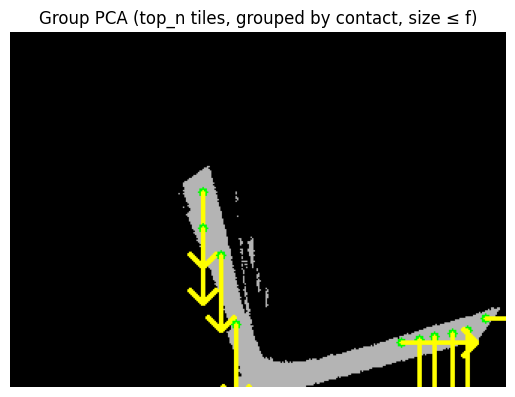

In [819]:



import numpy as np

def _grid_top_tiles_group_pca(binary_img, grid_rc=(10,10), top_n=40, min_pts=15,
                              f=3, connectivity=4):
    """
    1) Split image into grid
    2) Keep top_n heaviest tiles
    3) Merge touching kept tiles into groups of up to f tiles (chunk large components)
    4) For each group: concatenate all FG points and compute a single PCA (major eigenvector)

    Returns:
      groups: list of dicts:
        {
          'mass': int,                         # total mass in the group
          'centroid': (x, y),                  # center of mass of merged area
          'dir': np.array([dx, dy], float32),  # unit major eigenvector
          'evals': np.array([λ1, λ2], float32),
          'tile_indices': [indices into kept_tiles],
          'tiles': [per-tile dicts: gi, gj, box, mass]  # convenience
        }
      kept_tiles: list of kept tile dicts (sorted by mass desc)
    """
    H, W = binary_img.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)

    I = (binary_img > 0).astype(np.uint8)

    # --- collect tiles with their points
    tiles = []
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]
            x0, x1 = xs[gj], xs[gj+1]
            roi = I[y0:y1, x0:x1]
            mass = int(roi.sum())
            if mass <= 0:
                continue
            yy, xx = np.nonzero(roi)
            if len(xx) < min_pts:
                continue
            pts = np.column_stack([xx + x0, yy + y0]).astype(np.float32)
            tiles.append({
                'gi': gi, 'gj': gj,
                'box': (y0, y1, x0, x1),
                'mass': mass,
                'points': pts
            })

    if not tiles:
        return [], []

    # --- keep only top_n by mass
    tiles.sort(key=lambda d: d['mass'], reverse=True)
    kept_tiles = tiles[:min(top_n, len(tiles))]

    # --- build adjacency among kept tiles
    idx_by_cell = {(t['gi'], t['gj']): k for k, t in enumerate(kept_tiles)}
    neigh4 = [(1,0), (-1,0), (0,1), (0,-1)]
    neigh8 = neigh4 + [(1,1), (1,-1), (-1,1), (-1,-1)]
    neigh = neigh4 if connectivity == 4 else neigh8

    N = len(kept_tiles)
    used = np.zeros(N, dtype=bool)
    groups = []

    # traverse connected components; split each comp into chunks of size f
    for s in range(N):
        if used[s]:
            continue
        # BFS to get the whole component in kept-tiles space
        comp = []
        q = [s]
        used[s] = True
        while q:
            i = q.pop()
            comp.append(i)
            gi, gj = kept_tiles[i]['gi'], kept_tiles[i]['gj']
            for di, dj in neigh:
                ni, nj = gi + di, gj + dj
                j = idx_by_cell.get((ni, nj))
                if j is None or used[j]:
                    continue
                used[j] = True
                q.append(j)

        # split this component into chunks of size f
        for k in range(0, len(comp), max(1, f)):
            chunk = comp[k:k+f]
            # gather points and masses
            pts = [kept_tiles[idx]['points'] for idx in chunk]
            all_pts = np.vstack(pts) if len(pts) > 1 else pts[0]
            mass_sum = int(sum(kept_tiles[idx]['mass'] for idx in chunk))
            if len(all_pts) < 2:
                continue
            # PCA on merged area
            mu = all_pts.mean(axis=0)
            X = all_pts - mu
            COV = (X.T @ X) / len(all_pts)
            evals, evecs = np.linalg.eigh(COV)  # ascending
            v_major = evecs[:, 1]
            v_major = v_major / (np.linalg.norm(v_major) + 1e-12)

            groups.append({
                'mass': mass_sum,
                'centroid': (float(mu[0]), float(mu[1])),
                'dir': v_major.astype(np.float32),
                'evals': evals.astype(np.float32),
                'tile_indices': chunk,
                'tiles': [kept_tiles[idx] for idx in chunk],
            })

    return groups, kept_tiles


    
groups, kept = _grid_top_tiles_group_pca(
    binary_img=(image > 0).astype(np.uint8),
    grid_rc=(60,60),
    top_n=40,     # keep only the best N tiles
    min_pts=15,
    f=30,          # groups of up to f touching tiles
    connectivity=8  # or 8
)

# visualize arrows for each group's eigenvector
import cv2, matplotlib.pyplot as plt
vis = cv2.cvtColor(((image > 0).astype(np.uint8) * 180), cv2.COLOR_GRAY2BGR)
for g in groups:
    cx, cy = g['centroid']; dx, dy = g['dir']
    p0 = (int(round(cx)), int(round(cy)))
    p1 = (int(round(cx + 50*dx)), int(round(cy + 50*dy)))
    cv2.circle(vis, p0, 3, (0,255,0), -1)
    cv2.arrowedLine(vis, p0, p1, (0,255,255), 2, tipLength=0.25)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Group PCA (top_n tiles, grouped by contact, size ≤ f)")
plt.axis('off'); plt.show()


In [814]:
tiles

[{'gi': 11,
  'gj': 6,
  'box': (216, 236, 165, 192),
  'mass': 481,
  'centroid': (177.50103759765625, 226.536376953125),
  'dir': array([-0.9914709 , -0.13032891], dtype=float32)},
 {'gi': 11,
  'gj': 7,
  'box': (216, 236, 192, 220),
  'mass': 450,
  'centroid': (204.9844512939453, 224.74000549316406),
  'dir': array([-0.9616601,  0.2742442], dtype=float32)},
 {'gi': 10,
  'gj': 10,
  'box': (196, 216, 275, 302),
  'mass': 410,
  'centroid': (286.99267578125, 203.31219482421875),
  'dir': array([-0.9781911,  0.2077071], dtype=float32)},
 {'gi': 5,
  'gj': 4,
  'box': (98, 118, 110, 137),
  'mass': 399,
  'centroid': (126.02005004882812, 107.37593841552734),
  'dir': array([-0.82348615, -0.5673364 ], dtype=float32)},
 {'gi': 10,
  'gj': 9,
  'box': (196, 216, 247, 275),
  'mass': 391,
  'centroid': (261.8312072753906, 208.1892547607422),
  'dir': array([-0.97567624,  0.21921673], dtype=float32)},
 {'gi': 10,
  'gj': 5,
  'box': (196, 216, 137, 165),
  'mass': 328,
  'centroid': (154.

In [ ]:
plt.imshow(out["polyline"])

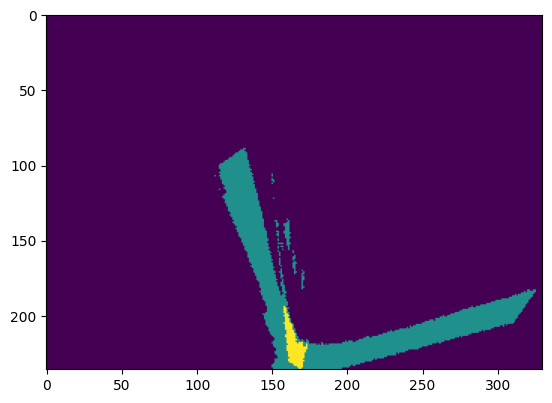

In [755]:
plt.imshow(image)

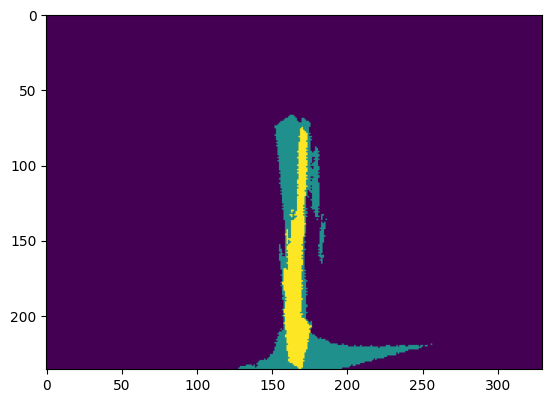

In [751]:
plt.imshow(combined_list[90])

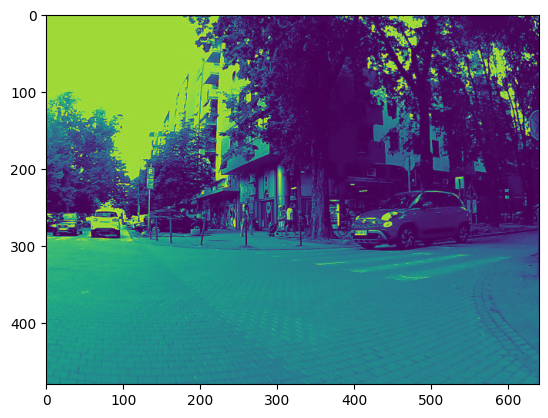

In [162]:
plt.imshow(gray_tensor[n])

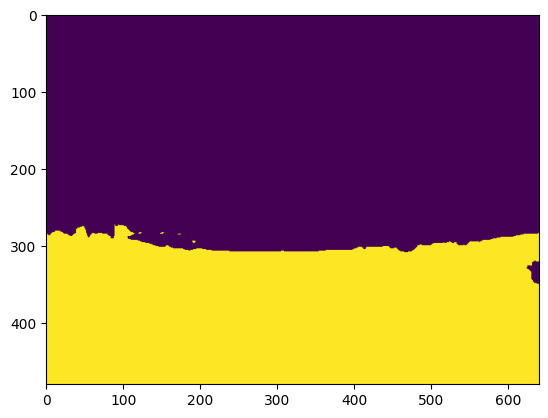

In [165]:
plt.imshow(np.equal(segmened_video[n], 0))

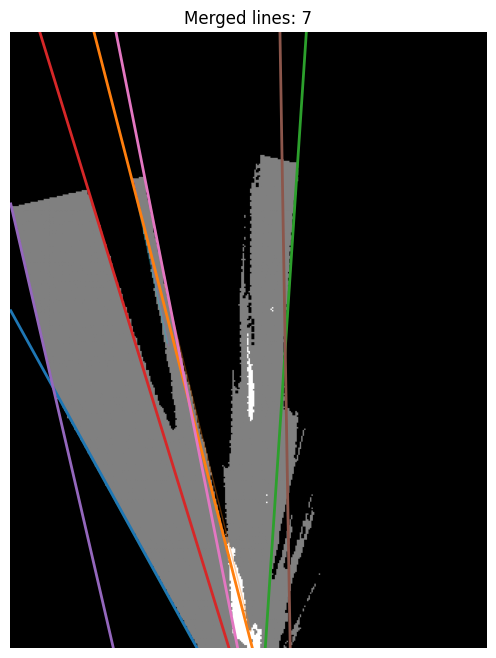

In [326]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import numpy as np
import cv2
import matplotlib.pyplot as plt

def hough_segments(
    img,
    sigma=4,
    low=60,
    high=180,
    min_len=30,
    max_gap=8,
    apply_closing=False,       # New flag to do dilate + erode
    morph_kernel_size=3,       # odd integer (3,5,7,...)
    morph_iters=1
):
    img = np.uint8(img)
    
    # Gaussian blur
    blur = cv2.GaussianBlur(img, (0, 0), sigma)

    # Morphological Closing: Dilation → Erosion
    morphed_blur = blur.copy()
    if apply_closing:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (morph_kernel_size, morph_kernel_size))
        morphed_blur = cv2.dilate(morphed_blur, kernel, iterations=morph_iters)
        morphed_blur = cv2.erode(morphed_blur, kernel, iterations=morph_iters)

    # Edge detection
    edges = cv2.Canny(morphed_blur, low, high)

    # Hough line detection
    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi / 180,
        threshold=40, minLineLength=min_len, maxLineGap=max_gap
    )
    segs = [] if lines is None else [l[0] for l in lines]
    return img, blur, morphed_blur, edges, segs

import numpy as np
import cv2
from collections import defaultdict

def _segment_features(segs):
    """
    For each (x1,y1,x2,y2) produce:
      - mid: midpoint
      - dir: unit direction with angle in [0, pi)
      - theta: angle (radians)
      - n: unit normal (perp) so that line has offset c = n·p
      - c: offset (using midpoint)
    """
    feats = []
    for (x1,y1,x2,y2) in segs:
        p1 = np.array([float(x1), float(y1)])
        p2 = np.array([float(x2), float(y2)])
        v  = p2 - p1
        nv = np.linalg.norm(v)
        if nv < 1e-6:
            continue
        d  = v / nv
        # canonical direction (angle in [0,pi))
        theta = np.arctan2(d[1], d[0])
        if theta < 0:
            theta += np.pi
        # recompute d from canonical angle (ensures d ~ opposite treated same)
        d = np.array([np.cos(theta), np.sin(theta)], dtype=float)

        # unit normal
        n = np.array([-d[1], d[0]], dtype=float)
        mid = 0.5*(p1+p2)
        c = float(n @ mid)
        feats.append({
            "p1": p1, "p2": p2,
            "mid": mid, "dir": d, "theta": theta,
            "n": n, "c": c
        })
    return feats

def _bucket_key(theta, c, angle_tol_deg, dist_tol):
    # bin by angle and line offset
    angle_bin = int(round(theta / np.deg2rad(angle_tol_deg)))
    c_bin     = int(round(c / float(dist_tol)))
    return (angle_bin, c_bin)

def _cluster_segments(segs, angle_tol_deg=5.0, dist_tol=10.0):
    """
    Cheap agglomeration by (angle ~ and offset ~).
    Returns list of clusters, each cluster is a list of feature dicts.
    """
    feats = _segment_features(segs)
    buckets = defaultdict(list)
    for f in feats:
        key = _bucket_key(f["theta"], f["c"], angle_tol_deg, dist_tol)
        buckets[key].append(f)
    # optional small refinement: split bucket by actual |Δc| and |Δθ| if needed
    return list(buckets.values())

def _principal_direction(points):
    """
    PCA first component as dominant direction (unit length).
    """
    pts = np.asarray(points, dtype=float)
    ctr = pts.mean(axis=0)
    U, S, Vt = np.linalg.svd(pts - ctr, full_matrices=False)
    d = Vt[0]
    # canonicalize to [0,pi)
    if d[0] < 0:
        d = -d
    return ctr, d / np.linalg.norm(d)

def _project_bounds(points, origin, d):
    """
    Project points onto direction d (unit). Return t_min, t_max and endpoints.
    """
    v = d / np.linalg.norm(d)
    t = (points - origin) @ v
    tmin, tmax = t.min(), t.max()
    p0 = origin + tmin * v
    p1 = origin + tmax * v
    return p0, p1

def _extend_to_image_bounds(p, d, h, w):
    """
    Given a line p + t d (d unit), intersect with image rectangle [0,w-1]x[0,h-1].
    Return two endpoints clipped to image.
    """
    px, py = p
    dx, dy = d
    eps = 1e-12
    candidates = []

    def add_if_in_bounds(x, y):
        if -1e-6 <= x <= w-1+1e-6 and -1e-6 <= y <= h-1+1e-6:
            candidates.append(np.array([x, y], dtype=float))

    # x = 0, x = w-1
    if abs(dx) > eps:
        t0 = (0.0   - px) / dx
        y0 = py + t0*dy
        add_if_in_bounds(0.0, y0)

        t1 = ((w-1) - px) / dx
        y1 = py + t1*dy
        add_if_in_bounds(w-1, y1)

    # y = 0, y = h-1
    if abs(dy) > eps:
        t2 = (0.0   - py) / dy
        x2 = px + t2*dx
        add_if_in_bounds(x2, 0.0)

        t3 = ((h-1) - py) / dy
        x3 = px + t3*dx
        add_if_in_bounds(x3, h-1)

    # pick the two farthest distinct points
    if len(candidates) < 2:
        return None
    # unique-ish
    uniq = []
    for q in candidates:
        if not any(np.linalg.norm(q - r) < 1e-6 for r in uniq):
            uniq.append(q)
    if len(uniq) < 2:
        return None

    # farthest pair
    dmax, pair = -1, (uniq[0], uniq[1])
    for i in range(len(uniq)):
        for j in range(i+1, len(uniq)):
            dist = np.linalg.norm(uniq[i]-uniq[j])
            if dist > dmax:
                dmax, pair = dist, (uniq[i], uniq[j])
    return pair[0], pair[1]

def merge_and_extend_segments(
    segs,
    img_shape,                 # (H, W)
    angle_tol_deg=5.0,
    dist_tol=10.0,
    extend_mode="image",       # "image" | "pad"
    extra_extend_px=0          # if extend_mode="pad", extend this many px each side
):
    """
    Merge near-collinear, near-coincident segments; extend result.
    Returns list of (x1,y1,x2,y2) ints.
    """
    if not segs:
        return []

    clusters = _cluster_segments(segs, angle_tol_deg=angle_tol_deg, dist_tol=dist_tol)
    H, W = img_shape[:2]
    merged = []

    for cl in clusters:
        # Collect all endpoints in this cluster
        pts = []
        for f in cl:
            pts.append(f["p1"]); pts.append(f["p2"])
        pts = np.vstack(pts)

        # Robust direction via PCA
        origin, d = _principal_direction(pts)

        # Span across existing points
        p0, p1 = _project_bounds(pts, origin, d)

        # Optional extra extension
        if extend_mode == "pad" and extra_extend_px > 0:
            p0 = p0 - d * extra_extend_px
            p1 = p1 + d * extra_extend_px

        # Clip/extend to image bounds if requested
        if extend_mode == "image":
            clipped = _extend_to_image_bounds((p0+p1)/2.0, d, H, W)
            if clipped is not None:
                p0, p1 = clipped

        x1,y1 = np.clip(np.round(p0), [0,0], [W-1, H-1]).astype(int)
        x2,y2 = np.clip(np.round(p1), [0,0], [W-1, H-1]).astype(int)
        if (x1!=x2 or y1!=y2):
            merged.append((x1,y1,x2,y2))

    return merged


def plot_all_stages_blur(img, blur, morphed_blur, edges, segs):
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(blur, cmap='gray')
    plt.title("Blurred")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(morphed_blur, cmap='gray')
    plt.title("Dilate → Erode (Closing)")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(img, cmap='gray')
    for (x1, y1, x2, y2) in segs:
        plt.plot([x1, x2], [y1, y2], linewidth=2)
    plt.title(f"{len(segs)} Hough Lines")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

img, blur, morphed_blur, edges, segs = hough_segments(
    np.uint8(100*tensor_hwn[:, :, n]),
    sigma=2,
    apply_closing=True,
    morph_kernel_size=9,
    morph_iters=2,
    min_len=100,
    max_gap=70
)

merged = merge_and_extend_segments(
    segs,
    img_shape=img.shape,       # (H, W)
    angle_tol_deg=6.0,         # tweak: 3–10 degrees typical
    dist_tol=12.0,             # pixels: how close in offset (parallel lines) to merge
    extend_mode="image",       # extend to full image borders
    extra_extend_px=0          # use if extend_mode="pad"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(img, cmap='gray')
for (x1,y1,x2,y2) in segs:
    plt.plot([x1,x2],[y1,y2], linewidth=1, alpha=0.35)
for (x1,y1,x2,y2) in merged:
    plt.plot([x1,x2],[y1,y2], linewidth=2)  # merged in thicker line
plt.axis('off'); plt.title(f"Merged lines: {len(merged)}")
plt.show()


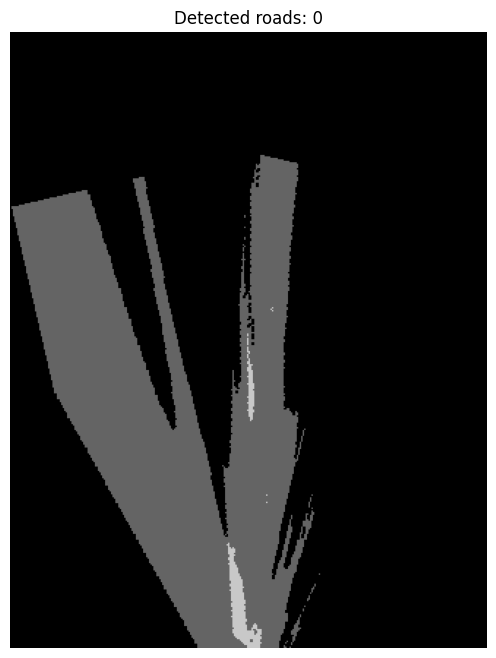

In [327]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def _line_angle(x1,y1,x2,y2):
    # angle in [0, pi)
    a = np.arctan2(y2 - y1, x2 - x1)
    if a < 0: a += np.pi
    return a

def _pair_endpoints_as_quad(a, b):
    """
    Given two segments a=(x1,y1,x2,y2), b=(u1,v1,u2,v2) assumed (near) parallel,
    return a convex 4-pt polygon by pairing closest ends.
    """
    a0 = np.array([a[0], a[1]], dtype=float)
    a1 = np.array([a[2], a[3]], dtype=float)
    b0 = np.array([b[0], b[1]], dtype=float)
    b1 = np.array([b[2], b[3]], dtype=float)

    # two possible pairings: (a0-b0, a1-b1) vs (a0-b1, a1-b0)
    cost1 = np.linalg.norm(a0-b0) + np.linalg.norm(a1-b1)
    cost2 = np.linalg.norm(a0-b1) + np.linalg.norm(a1-b0)

    if cost1 <= cost2:
        q0, q1 = b0, b1
    else:
        q0, q1 = b1, b0

    # polygon order: a0 -> a1 -> q1 -> q0 (roughly a strip)
    poly = np.stack([a0, a1, q1, q0], axis=0).astype(np.float32)
    return poly

def detect_road_polygons(
    img_gray_u8,           # uint8, same size as lines come from
    lines,                 # list of (x1,y1,x2,y2) merged/extended segments
    angle_thresh_deg=6.0,  # max angle diff to consider "parallel"
    white_thresh=180,      # threshold for "white" pixels (0-255)
    white_pct_thresh=0.55  # % of white pixels required inside the strip
):
    H, W = img_gray_u8.shape[:2]
    white_mask = (img_gray_u8 >= white_thresh).astype(np.uint8)  # 0/1

    # Precompute angles
    angles = [ _line_angle(*l) for l in lines ]
    angle_thresh = np.deg2rad(angle_thresh_deg)

    road_polys = []  # list of Nx2 float32 polygons

    for i in range(len(lines)):
        for j in range(i+1, len(lines)):
            a = lines[i]; b = lines[j]
            da = angles[i]; db = angles[j]
            d = abs(da - db)
            d = min(d, np.pi - d)  # wrap

            if d > angle_thresh:
                continue

            poly = _pair_endpoints_as_quad(a, b)

            # clip polygon to image and rasterize mask
            poly_int = np.round(poly).astype(np.int32)
            poly_int[:,0] = np.clip(poly_int[:,0], 0, W-1)
            poly_int[:,1] = np.clip(poly_int[:,1], 0, H-1)

            region_mask = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(region_mask, [poly_int], 1)

            area = int(region_mask.sum())
            if area == 0:
                continue

            white_in_region = int((white_mask & region_mask).sum())
            pct = white_in_region / float(area)

            if pct >= white_pct_thresh:
                road_polys.append(poly)  # keep float32 polygon

    return road_polys

def draw_road_polygons(img_gray_u8, road_polys, line_color=(0,255,0), alpha=0.35):
    """Overlay semi-transparent polygons and their borders on top of a grayscale image."""
    img_color = cv2.cvtColor(img_gray_u8, cv2.COLOR_GRAY2BGR)
    overlay = img_color.copy()

    for poly in road_polys:
        poly_i = np.round(poly).astype(np.int32)
        cv2.fillPoly(overlay, [poly_i], color=line_color)
        cv2.polylines(img_color, [poly_i], isClosed=True, color=(0,180,0), thickness=2)

    out = cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0)
    return out


# After you have segs (raw) and merged (extended-to-image) segments:
# merged = merge_and_extend_segments(segs, img.shape, ...)

# Classify roads and draw polygons
road_polys = detect_road_polygons(
    img_gray_u8=img,               # use original or morphed_blur if you prefer
    lines=merged,
    angle_thresh_deg=20.0,          # tweak: 3–10
    white_thresh=185,              # depends on your image dynamic range
    white_pct_thresh=0.55          # raise if too many false positives
)

vis = draw_road_polygons(img, road_polys, line_color=(0,255,0), alpha=0.35)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title(f"Detected roads: {len(road_polys)}")
plt.show()


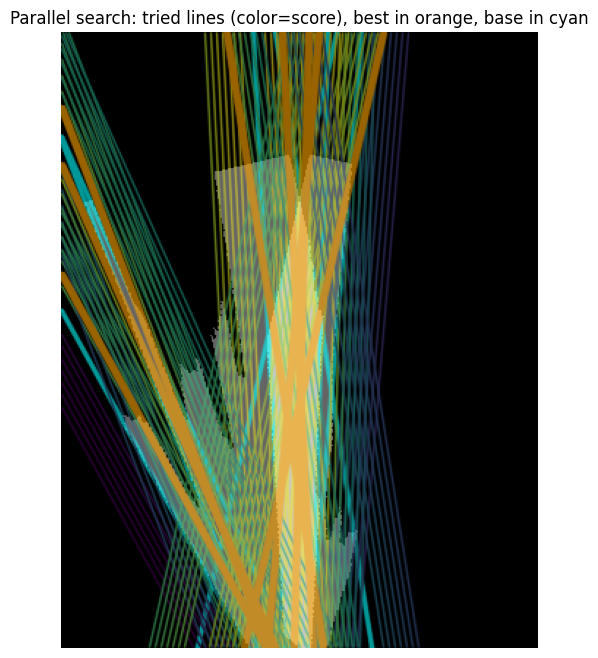

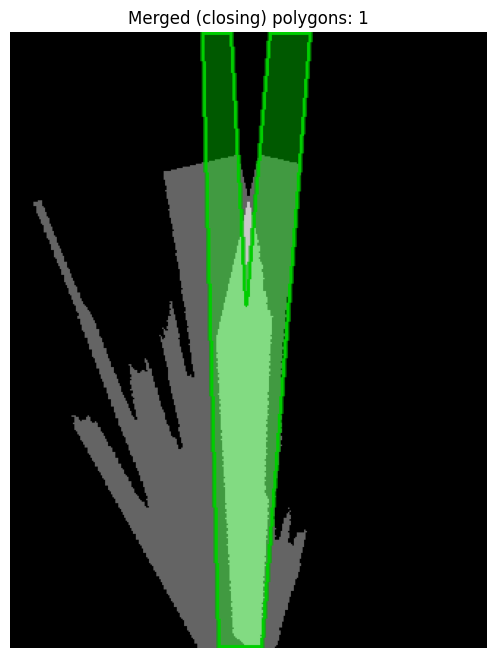

In [281]:
import numpy as np
import cv2

# --- geometry helpers ---
def _unit_dir_and_normal(x1,y1,x2,y2):
    v = np.array([x2-x1, y2-y1], dtype=float)
    nv = np.linalg.norm(v) + 1e-12
    d = v / nv
    if d[0] < 0:  # canonicalize to keep normals consistent-ish
        d = -d
    n = np.array([-d[1], d[0]], dtype=float)  # rotate +90°
    return d, n

def _extend_to_image_bounds(p, d, H, W):
    """Intersect infinite line p + t d with image rect; return endpoints or None."""
    px, py = float(p[0]), float(p[1])
    dx, dy = float(d[0]), float(d[1])
    cand = []

    def add(x,y):
        if -1e-6 <= x <= W-1+1e-6 and -1e-6 <= y <= H-1+1e-6:
            cand.append(np.array([x,y], float))

    eps = 1e-12
    if abs(dx) > eps:
        t = (0 - px)/dx; add(0, py + t*dy)
        t = ((W-1) - px)/dx; add(W-1, py + t*dy)
    if abs(dy) > eps:
        t = (0 - py)/dy; add(px + t*dx, 0)
        t = ((H-1) - py)/dy; add(px + t*dx, H-1)

    # unique and farthest pair
    if len(cand) < 2: return None
    uniq = []
    for q in cand:
        if not any(np.linalg.norm(q-r) < 1e-6 for r in uniq):
            uniq.append(q)
    if len(uniq) < 2: return None
    best = (uniq[0], uniq[1]); dmax = -1
    for i in range(len(uniq)):
        for j in range(i+1, len(uniq)):
            dist = np.linalg.norm(uniq[i]-uniq[j])
            if dist > dmax:
                dmax = dist; best = (uniq[i], uniq[j])
    return best[0], best[1]

def _shift_and_clip_parallel(line, offset_px, H, W):
    """Shift a segment along its unit normal by offset and extend to image bounds."""
    x1,y1,x2,y2 = line
    d, n = _unit_dir_and_normal(x1,y1,x2,y2)
    mid = np.array([(x1+x2)/2.0, (y1+y2)/2.0], float)
    p = mid + n * offset_px
    res = _extend_to_image_bounds(p, d, H, W)
    if res is None: return None
    q0, q1 = res
    return (float(q0[0]), float(q0[1]), float(q1[0]), float(q1[1]))

def _rasterize_poly(poly, H, W):
    pm = np.zeros((H,W), np.uint8)
    cv2.fillPoly(pm, [np.round(poly).astype(np.int32)], 1)
    return pm

def _polygon_iou(polyA, polyB, H, W):
    a = _rasterize_poly(polyA, H, W)
    b = _rasterize_poly(polyB, H, W)
    inter = (a & b).sum()
    union = (a | b).sum()
    if union == 0: return 0.0
    return inter / float(union)

def detect_road_polygons_with_pairs(
    img_gray_u8,
    lines,                  # list[(x1,y1,x2,y2)]
    angle_thresh_deg=6.0,
    white_thresh=180,
    white_pct_thresh=0.55
):
    H, W = img_gray_u8.shape[:2]
    white_mask = (img_gray_u8 >= white_thresh).astype(np.uint8)
    angles = [_line_angle(*l) for l in lines]
    angle_thresh = np.deg2rad(angle_thresh_deg)

    road_polys = []
    used_pairs = []
    used_line_ids = set()

    for i in range(len(lines)):
        for j in range(i+1, len(lines)):
            da = angles[i]; db = angles[j]
            d = abs(da - db); d = min(d, np.pi - d)
            if d > angle_thresh: continue

            poly = _pair_endpoints_as_quad(lines[i], lines[j])

            poly_i = np.round(poly).astype(np.int32)
            poly_i[:,0] = np.clip(poly_i[:,0], 0, W-1)
            poly_i[:,1] = np.clip(poly_i[:,1], 0, H-1)

            region_mask = np.zeros((H, W), np.uint8)
            cv2.fillPoly(region_mask, [poly_i], 1)
            area = int(region_mask.sum())
            if area == 0: continue

            white_in = int((white_mask & region_mask).sum())
            pct = white_in / float(area)
            if pct >= white_pct_thresh:
                road_polys.append(poly.astype(np.float32))
                used_pairs.append((i,j))
                used_line_ids.add(i); used_line_ids.add(j)

    return road_polys, used_pairs, used_line_ids




def augment_road_polygons_by_parallel_search(
    img_gray_u8,
    lines,                      # list[(x1,y1,x2,y2)]
    unused_line_ids: set[int],
    # classification params
    white_thresh=180,
    white_pct_thresh=0.55,
    # search params
    offsets_px=None,            # list of distances to try on each side
    width_min_px=8,
    width_max_px=200,
    # dedupe
    existing_polys=None,
    iou_dedupe_thresh=0.30
):
    """
    Returns list of extra polygons (float32 Nx2).
    """
    H, W = img_gray_u8.shape[:2]
    white_mask = (img_gray_u8 >= white_thresh).astype(np.uint8)
    if offsets_px is None:
        # equally spaced distances, tweak as needed
        offsets_px = [8, 12, 16, 20, 24, 28, 32]

    if existing_polys is None:
        existing_polys = []

    extra_polys = []

    for idx in sorted(unused_line_ids):
        base = lines[idx]
        best = (0.0, None)  # (pct, poly)

        for sgn in (+1, -1):
            for dpx in offsets_px:
                if not (width_min_px <= dpx <= width_max_px):
                    continue
                partner = _shift_and_clip_parallel(base, sgn * dpx, H, W)
                if partner is None: continue

                poly = _pair_endpoints_as_quad(base, partner)
                poly_i = np.round(poly).astype(np.int32)
                poly_i[:,0] = np.clip(poly_i[:,0], 0, W-1)
                poly_i[:,1] = np.clip(poly_i[:,1], 0, H-1)

                region = np.zeros((H,W), np.uint8)
                cv2.fillPoly(region, [poly_i], 1)
                area = int(region.sum())
                if area == 0: continue

                white_in = int((white_mask & region).sum())
                pct = white_in / float(area)

                if pct > best[0]:
                    best = (pct, poly.astype(np.float32))

        # keep best if above threshold and not duplicate
        if best[1] is not None and best[0] >= white_pct_thresh:
            poly_best = best[1]
            # IoU de-duplication vs existing and already accepted extra
            dup = False
            for p in (existing_polys + extra_polys):
                if _polygon_iou(poly_best, p, H, W) >= iou_dedupe_thresh:
                    dup = True; break
            if not dup:
                extra_polys.append(poly_best)

    return extra_polys





import numpy as np
import cv2

def augment_road_polygons_by_parallel_search(
    img_gray_u8,
    lines,                      # list[(x1,y1,x2,y2)]
    unused_line_ids: set[int],
    # classification params
    white_thresh=180,
    white_pct_thresh=0.55,
    # selection param (NEW): score = pct + count_coeff * white_count
    count_coeff=0.0,
    # search params
    offsets_px=None,            # list of distances to try on each side
    width_min_px=8,
    width_max_px=200,
    # dedupe
    existing_polys=None,
    iou_dedupe_thresh=0.30
):
    """
    Returns:
      extra_polys:    list of accepted polygons (float32 Nx2)
      tried_records:  list of dicts with keys:
                      { 'base_idx', 'line':(x1,y1,x2,y2), 'pct', 'white_count',
                        'score', 'offset_px', 'side', 'is_best' }
      best_map:       dict base_idx -> best tried record (same dict as above)
    Selection uses: score = pct + count_coeff * white_count
    Acceptance still uses: pct >= white_pct_thresh
    """
    H, W = img_gray_u8.shape[:2]
    white_mask = (img_gray_u8 >= white_thresh).astype(np.uint8)
    if offsets_px is None:
        offsets_px = [8, 12, 16, 20, 24, 28, 32]

    if existing_polys is None:
        existing_polys = []

    extra_polys = []
    tried_records = []
    best_map = {}

    for idx in sorted(unused_line_ids):
        base = lines[idx]
        best_score = -1.0
        best_pct   = -1.0
        best_poly  = None
        best_rec   = None

        # try both sides (+1, -1)
        for sgn in (+1, -1):
            for dpx in offsets_px:
                if not (width_min_px <= dpx <= width_max_px):
                    continue
                partner = _shift_and_clip_parallel(base, sgn * dpx, H, W)
                if partner is None:
                    continue

                poly = _pair_endpoints_as_quad(base, partner)
                poly_i = np.round(poly).astype(np.int32)
                poly_i[:,0] = np.clip(poly_i[:,0], 0, W-1)
                poly_i[:,1] = np.clip(poly_i[:,1], 0, H-1)

                region = np.zeros((H, W), np.uint8)
                cv2.fillPoly(region, [poly_i], 1)
                area = int(region.sum())
                if area == 0:
                    continue

                white_in = int((white_mask & region).sum())
                pct = white_in / float(area)
                score = pct + count_coeff * float(white_in)

                rec = {
                    'base_idx': idx,
                    'line': partner,
                    'pct': float(pct),
                    'white_count': int(white_in),
                    'score': float(score),
                    'offset_px': float(sgn * dpx),
                    'side': int(sgn),      # +1 or -1
                    'is_best': False
                }
                tried_records.append(rec)

                # choose by score (NEW)
                if score > best_score:
                    best_score = score
                    best_pct   = pct
                    best_poly  = poly.astype(np.float32)
                    best_rec   = rec

        # always record the best for visualization, even if below pct threshold
        if best_rec is not None:
            best_rec = dict(best_rec)
            best_rec['is_best'] = True
            best_map[idx] = best_rec

        # accept polygon only if it passes cleanliness gate
        if best_poly is not None and best_pct >= white_pct_thresh:
            # IoU de-dup vs existing and already accepted
            dup = False
            for p in (existing_polys + extra_polys):
                if _polygon_iou(best_poly, p, H, W) >= iou_dedupe_thresh:
                    dup = True; break
            if not dup:
                extra_polys.append(best_poly)

    return extra_polys, tried_records, best_map




import matplotlib.pyplot as plt

def _to_bgr_from_cmap(val01, cmap_name="viridis"):
    """Map 0..1 -> BGR color using a matplotlib colormap."""
    val01 = float(np.clip(val01, 0.0, 1.0))
    cmap = plt.get_cmap(cmap_name)
    r, g, b, _ = cmap(val01)
    return (int(b*255), int(g*255), int(r*255))

def draw_tried_parallel_lines(
    img_gray_u8,
    base_lines,                 # list of (x1,y1,x2,y2) for the unused set you searched
    tried_records,              # from augment_road_polygons_by_parallel_search
    best_map=None,
    alpha=0.6,
    cmap_name="viridis",
    base_color=(255,255,0),     # cyan for base lines
    best_color=(0,165,255)      # orange for the chosen partner
):
    """
    Returns BGR image overlay:
      - base lines: thick cyan
      - all tried partner lines: thin, colored by pct (low=dark, high=bright)
      - best chosen partner per base: thicker orange
    """
    img_color = cv2.cvtColor(img_gray_u8, cv2.COLOR_GRAY2BGR)
    overlay = img_color.copy()

    # draw base lines
    for (x1,y1,x2,y2) in base_lines:
        cv2.line(overlay, (int(x1),int(y1)), (int(x2),int(y2)), base_color, 2, cv2.LINE_AA)

    if tried_records:
        pcts = [rec['pct'] for rec in tried_records]
        pmin, pmax = float(min(pcts)), float(max(pcts))
        if pmax <= pmin:  # avoid div-by-zero
            pmax = pmin + 1e-6

        # draw all tried (color by pct)
        for rec in tried_records:
            x1,y1,x2,y2 = map(int, rec['line'])
            val01 = (rec['pct'] - pmin) / (pmax - pmin)
            color = _to_bgr_from_cmap(val01, cmap_name)
            cv2.line(overlay, (x1,y1), (x2,y2), color, 1, cv2.LINE_AA)

    # highlight best chosen
    if best_map:
        for base_idx, rec in best_map.items():
            x1,y1,x2,y2 = map(int, rec['line'])
            cv2.line(overlay, (x1,y1), (x2,y2), best_color, 3, cv2.LINE_AA)

    out = cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0)
    return out




def _poly_white_stats(poly, img_gray_u8, white_thresh=180):
    """
    Returns (area_px, white_in_px, pct_white) for polygon `poly` on `img_gray_u8`.
    """
    H, W = img_gray_u8.shape[:2]
    poly_i = np.round(poly).astype(np.int32)
    poly_i[:,0] = np.clip(poly_i[:,0], 0, W-1)
    poly_i[:,1] = np.clip(poly_i[:,1], 0, H-1)

    region = np.zeros((H, W), np.uint8)
    cv2.fillPoly(region, [poly_i], 1)

    area = int(region.sum())
    if area == 0:
        return 0, 0, 0.0

    white_mask = (img_gray_u8 >= white_thresh).astype(np.uint8)
    white_in = int((white_mask & region).sum())
    pct = white_in / float(area)
    return area, white_in, float(pct)


def _poly_quality(area_px, white_in_px, pct_white, count_coeff=0.0):
    """
    Quality metric: prioritize high percentage first, then reward absolute count.
    By default score = pct_white + count_coeff * white_in_px (tunable coeff).
    """
    return float(pct_white + count_coeff * float(white_in_px))


def rank_and_suppress_polys(
    polys,                   # list of Nx2 float32 polygons
    img_gray_u8,
    white_thresh=180,
    iou_thresh=0.50,
    min_pct=0.0,
    min_white=0,
    count_coeff=0.0
):
    """
    - Computes stats (area, white_in, pct) for each poly.
    - Computes quality score = pct + count_coeff * white_in.
    - Sorts polys by (pct desc, white_in desc) i.e. by score (ties by pct/white).
    - Runs NMS by IoU: for overlaps >= iou_thresh, keeps the higher score, drops lower.
    - Also drops any poly below min_pct or min_white thresholds.

    Returns:
      kept_polys:  list of polygons kept
      dropped_idx: list of indices dropped (in original `polys` indexing)
      stats:       list of dicts per original index:
                   {'area':..., 'white_in':..., 'pct':..., 'score':...}
    """
    H, W = img_gray_u8.shape[:2]

    # Compute stats & scores
    stats = []
    for i, p in enumerate(polys):
        area, white_in, pct = _poly_white_stats(p, img_gray_u8, white_thresh=white_thresh)
        score = _poly_quality(area, white_in, pct, count_coeff=count_coeff)
        stats.append({'area': area, 'white_in': white_in, 'pct': pct, 'score': score})

    # Pre-filter by cleanliness gates
    valid_idx = [i for i, s in enumerate(stats) if (s['pct'] >= min_pct and s['white_in'] >= min_white and s['area'] > 0)]

    # Sort by quality (desc), tie-break by pct, then white_in
    valid_idx.sort(key=lambda i: (stats[i]['score'], stats[i]['pct'], stats[i]['white_in']), reverse=True)

    kept = []
    dropped = set()

    for i in valid_idx:
        if i in dropped:
            continue
        # compare to already kept and suppress if highly overlapping with a better one
        keep = True
        for j in kept:
            iou = _polygon_iou(polys[i], polys[j], H, W)
            if iou >= iou_thresh:
                # i is lower-ranked because we iterate in descending order and j is already kept
                keep = False
                dropped.add(i)
                break
        if keep:
            kept.append(i)

    kept_polys = [polys[i] for i in kept]
    dropped_idx = sorted(list(set(range(len(polys))) - set(kept)))
    return kept_polys, dropped_idx, stats









def _polys_to_mask(polys, H, W):
    m = np.zeros((H, W), np.uint8)
    for p in polys:
        if p is None or len(p) < 3: 
            continue
        pi = np.round(p).astype(np.int32)
        pi[:,0] = np.clip(pi[:,0], 0, W-1)
        pi[:,1] = np.clip(pi[:,1], 0, H-1)
        cv2.fillPoly(m, [pi], 1)
    return m

def _mask_to_polys(mask01, min_area_px=50, approx_eps_frac=0.01, retr_mode=cv2.RETR_EXTERNAL):
    """
    Converts a {0,1} mask to polygons. 
    - min_area_px filters tiny specks.
    - approx_eps_frac controls Douglas-Peucker simplification (0=off-ish, e.g. 0.0..0.02 good range).
    - retr_mode: RETR_EXTERNAL (no holes) or cv2.RETR_CCOMP if you want outer + holes.
    """
    mask_u8 = (mask01.astype(np.uint8) * 255)
    contours, hier = cv2.findContours(mask_u8, retr_mode, cv2.CHAIN_APPROX_SIMPLE)
    out = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < float(min_area_px):
            continue
        if approx_eps_frac and approx_eps_frac > 0.0:
            eps = approx_eps_frac * cv2.arcLength(c, True)
            c = cv2.approxPolyDP(c, eps, True)
        out.append(c.reshape(-1, 2).astype(np.float32))
    return out

def merge_polys_by_morph_close(
    polys, 
    H, W,
    close_radius_px=6,        # how aggressively to bridge gaps (≈ closes gaps up to ~2*radius)
    iterations=1,             # increase to strengthen closing
    min_area_px=80,           # filter tiny leftovers
    approx_eps_frac=0.01,     # simplify resulting polygons
    bridge_islands_px=None    # if set, do an extra dilate/erode with this radius to force joining
):
    """
    Morphological 'dilate+erode' to fuse nearby polygons, then re-vectorize.

    Tip: If your gap between polygons is ~g pixels, set close_radius_px ≈ ceil(g/2).
    """
    # 1) rasterize all input polys into a single mask
    mask = _polys_to_mask(polys, H, W)

    # 2) closing (dilate then erode) with elliptical kernel
    k = 2*int(close_radius_px) + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)

    # Optional: stronger “join islands” pass (pure dilation then erosion) to fuse components
    if bridge_islands_px is not None and bridge_islands_px > 0:
        kk = 2*int(bridge_islands_px) + 1
        Kb = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kk, kk))
        closed = cv2.dilate(closed, Kb, iterations=1)
        closed = cv2.erode(closed, Kb, iterations=1)

    # 3) re-extract polygons from the fused mask
    merged_polys = _mask_to_polys(
        (closed > 0).astype(np.uint8),
        min_area_px=min_area_px,
        approx_eps_frac=approx_eps_frac,
        retr_mode=cv2.RETR_EXTERNAL  # change to cv2.RETR_CCOMP if you want holes
    )
    return merged_polys, closed











# Step A: detect roads from real line pairs (and know which lines were used)
road_polys, used_pairs, used_line_ids = detect_road_polygons_with_pairs(
    img_gray_u8=img,
    lines=merged,
    angle_thresh_deg=20.0,
    white_thresh=185,
    white_pct_thresh=0.55
)

# Step B: search around unused lines; get extra polys AND all tried parallels
all_ids = set(range(len(merged)))
unused_ids = all_ids - used_line_ids

extra_polys, tried_records, best_map = augment_road_polygons_by_parallel_search(
    count_coeff = 0.000001,
    img_gray_u8=img,
    lines=merged,
    unused_line_ids=unused_ids,
    white_thresh=100,
    white_pct_thresh=0.30,
    offsets_px=[8,12,16,20,24,28,32],
    width_min_px=8,
    width_max_px=200,
    existing_polys=road_polys,
    iou_dedupe_thresh=0.30
)

# Step C: show all tried lines
unused_lines = [merged[i] for i in sorted(unused_ids)]
debug_vis = draw_tried_parallel_lines(
    img_gray_u8=img,
    base_lines=unused_lines,
    tried_records=tried_records,
    best_map=best_map,
    alpha=0.6,
    cmap_name="viridis"
)














plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title("Parallel search: tried lines (color=score), best in orange, base in cyan")
plt.show()

# Step D: final polygons (pairs + search)
all_polys = road_polys + extra_polys
vis = draw_road_polygons(img, all_polys, line_color=(0,255,0), alpha=0.35)

# Rank by %white + (tiny) count bonus, suppress overlaps by IoU
kept_polys, dropped_idx, stats = rank_and_suppress_polys(
    all_polys,
    img_gray_u8=img,
    white_thresh=180,     # or match your earlier threshold
    iou_thresh=0.2,      # "high IoU" threshold
    min_pct=0.30,         # optional cleanliness gate
    min_white=50,          # optional absolute count gate
    count_coeff=5e-6      # gentle preference for larger regions
)

H, W = img.shape[:2]

# Morphologically fuse near-by polygons (close small gaps), then redraw
merged_polys, fused_mask = merge_polys_by_morph_close(
    kept_polys,
    H, W,
    close_radius_px=0,      # try 4–10 depending on typical gap size
    iterations=1,
    min_area_px=100,
    approx_eps_frac=0.01,
    bridge_islands_px=None  # e.g., set to 8–12 if you want even more aggressive joining
)

vis_merged = draw_road_polygons(img, merged_polys, line_color=(0,255,0), alpha=0.35)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(vis_merged, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title(f"Merged (closing) polygons: {len(merged_polys)}")
plt.show()




In [11]:
merged

[(61, 0, 82, 394), (0, 129, 76, 394)]

In [747]:
import numpy as np
import cv2

def draw_road_areas(img_gray_u8, road_polys, fill_color=(0,255,0), alpha=0.35):
    """
    Fill road polygons and alpha-blend over the grayscale image.
    No edges/lines are drawn.
    """
    img_color = cv2.cvtColor(img_gray_u8, cv2.COLOR_GRAY2BGR)
    if not road_polys:
        return img_color
    overlay = img_color.copy()
    polys_i = [np.round(p).astype(np.int32) for p in road_polys]
    cv2.fillPoly(overlay, polys_i, fill_color)   # fill only
    return cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0)



import numpy as np
import cv2

def draw_road_areas(img_gray_u8, road_polys, fill_color=(0,255,0), alpha=0.35):
    """
    Fill road polygons and alpha-blend over the grayscale image.
    No edges/lines are drawn.
    """
    img_color = cv2.cvtColor(img_gray_u8, cv2.COLOR_GRAY2BGR)
    if not road_polys:
        return img_color
    overlay = img_color.copy()
    polys_i = [np.round(p).astype(np.int32) for p in road_polys]
    cv2.fillPoly(overlay, polys_i, fill_color)   # fill only
    return cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0)


def make_road_video(
    bev_cal_tensor,
    out_path="road_detection.mp4",
    fps=12,
    # --- Hough + preproc params ---
    sigma=2,
    apply_closing=True,
    morph_kernel_size=9,
    morph_iters=2,
    min_len=100,
    max_gap=70,
    # --- merge params ---
    angle_tol_deg=6.0,
    dist_tol=12.0,
    extend_mode="image",
    extra_extend_px=0,
    # --- pairing / classification params ---
    angle_thresh_deg=20.0,
    white_thresh=185,
    white_pct_thresh=0.55,
    # --- augmentation params ---
    do_augment=True,
    count_coeff=5e-4,
    offsets_px=(8,12,16,20,24,28,32),
    width_min_px=8,
    width_max_px=200,
    iou_dedupe_thresh=0.30,
    use_morphed_for_white=False,
    # --- ranking + suppression (NMS-for-polys) ---
    iou_nms_thresh=0.50,
    min_pct=0.30,
    min_white=50,
    count_coeff_rank=5e-6,
    # --- morphological merge of close polygons ---
    morph_close_radius=6,
    morph_close_iterations=1,
    morph_min_area_px=100,
    morph_approx_eps_frac=0.01,
    morph_bridge_islands_px=None,
    # --- drawing params ---
    overlay_color=(0,255,0),
    overlay_alpha=0.35,
    draw_raw_lines=False,
    draw_tried_lines=False,
    color_tried_by='score'
):
    """
    bev_cal_tensor: np.ndarray of shape (H, W, N), dtype uint8-compatible

    Side-effect: writes an MP4 with road polygons overlaid (filled only; no lines).
    Return: np.ndarray of shape (H, W, N), dtype=uint8, with 1 where polygon exists, else 0.
    """
    assert bev_cal_tensor.ndim == 3, "bev_cal_tensor must be HxWxN"
    H, W, N = bev_cal_tensor.shape

    def _lerp(a, b, t): return int(a + (b - a) * t)
    def _score_color(t01):
        t = float(np.clip(t01, 0.0, 1.0))
        return (_lerp(200,  20, t),  # B
                _lerp( 80, 255, t),  # G
                _lerp(255,  20, t))  # R

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for {out_path}")

    # --- NEW: collect per-frame binary masks here ---
    mask_frames = []

    for n in range(N):
        img = np.uint8(bev_cal_tensor[:, :, n].copy())

        # 1) Hough + preprocessing
        img_, blur, morphed_blur, edges, segs = hough_segments(
            img,
            sigma=sigma,
            apply_closing=apply_closing,
            morph_kernel_size=morph_kernel_size,
            morph_iters=morph_iters,
            min_len=min_len,
            max_gap=max_gap
        )

        # 2) Merge and extend segments
        merged = merge_and_extend_segments(
            segs,
            img_shape=img.shape,
            angle_tol_deg=angle_tol_deg,
            dist_tol=dist_tol,
            extend_mode=extend_mode,
            extra_extend_px=extra_extend_px
        )

        white_src = morphed_blur if use_morphed_for_white else img

        # 3) Polygons from real line pairs (+ optional augmentation)
        if do_augment:
            road_polys, used_pairs, used_line_ids = detect_road_polygons_with_pairs(
                img_gray_u8=white_src,
                lines=merged,
                angle_thresh_deg=angle_thresh_deg,
                white_thresh=white_thresh,
                white_pct_thresh=white_pct_thresh
            )
            all_ids = set(range(len(merged)))
            unused_ids = all_ids - used_line_ids

            extra_polys, tried_records, best_map = augment_road_polygons_by_parallel_search(
                img_gray_u8=white_src,
                lines=merged,
                unused_line_ids=unused_ids,
                white_thresh=white_thresh,
                white_pct_thresh=white_pct_thresh,
                count_coeff=count_coeff,
                offsets_px=list(offsets_px),
                width_min_px=width_min_px,
                width_max_px=width_max_px,
                existing_polys=road_polys,
                iou_dedupe_thresh=iou_dedupe_thresh
            )
            road_polys_all = road_polys + extra_polys
        else:
            road_polys_all = detect_road_polygons_with_pairs(
                img_gray_u8=white_src,
                lines=merged,
                angle_thresh_deg=angle_thresh_deg,
                white_thresh=white_thresh,
                white_pct_thresh=white_pct_thresh
            )[0]
            tried_records, best_map = [], {}

        # 4) Rank + suppress (NMS for polygons)
        kept_polys, dropped_idx, stats = rank_and_suppress_polys(
            road_polys_all,
            img_gray_u8=white_src,
            white_thresh=white_thresh,
            iou_thresh=iou_nms_thresh,
            min_pct=min_pct,
            min_white=min_white,
            count_coeff=count_coeff_rank
        )

        # 5) Morphologically fuse nearby polygons, then re-vectorize
        fused_polys, fused_mask = merge_polys_by_morph_close(
            kept_polys,
            H, W,
            close_radius_px=morph_close_radius,
            iterations=morph_close_iterations,
            min_area_px=morph_min_area_px,
            approx_eps_frac=morph_approx_eps_frac,
            bridge_islands_px=morph_bridge_islands_px
        )

        # --- NEW: build binary mask (0/1) for this frame ---
        if fused_mask is not None:
            # fused_mask may be 0/255; normalize to 0/1
            frame_mask01 = (fused_mask > 0).astype(np.uint8)
        else:
            # fallback: rasterize polygons if fused_mask not returned
            frame_mask01 = np.zeros((H, W), dtype=np.uint8)
            if fused_polys:
                polys_i = [np.round(p).astype(np.int32) for p in fused_polys]
                cv2.fillPoly(frame_mask01, polys_i, 1)

        mask_frames.append(frame_mask01)

        # 6) Draw filled areas (no lines) for the video
        vis = draw_road_areas(white_src if use_morphed_for_white else img,
                              fused_polys, fill_color=overlay_color, alpha=overlay_alpha)

        if draw_raw_lines:
            for (x1,y1,x2,y2) in segs:
                cv2.line(vis, (x1,y1), (x2,y2), (255,0,0), 1, cv2.LINE_AA)
            for (x1,y1,x2,y2) in merged:
                cv2.line(vis, (x1,y1), (x2,y2), (0,165,255), 2, cv2.LINE_AA)

        if do_augment and draw_tried_lines and tried_records:
            vals = [r.get(color_tried_by, 0.0) for r in tried_records]
            vmin, vmax = float(min(vals)), float(max(vals))
            if vmax <= vmin: vmax = vmin + 1e-6
            for r in tried_records:
                x1,y1,x2,y2 = map(int, r['line'])
                t01 = (r.get(color_tried_by, 0.0) - vmin) / (vmax - vmin)
                color = _score_color(t01)
                cv2.line(vis, (x1,y1), (x2,y2), color, 1, cv2.LINE_AA)
            for rec in best_map.values():
                x1,y1,x2,y2 = map(int, rec['line'])
                cv2.line(vis, (x1,y1), (x2,y2), (0,165,255), 3, cv2.LINE_AA)

        cv2.putText(vis, f"Frame {n+1}/{N} | Cand: {len(road_polys_all)}  NMS: {len(kept_polys)}  Fused: {len(fused_polys)}",
                    (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (0,0,0), 3, cv2.LINE_AA)
        cv2.putText(vis, f"Frame {n+1}/{N} | Cand: {len(road_polys_all)}  NMS: {len(kept_polys)}  Fused: {len(fused_polys)}",
                    (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (255,255,255), 1, cv2.LINE_AA)

        vis_bgr = vis if vis.ndim == 3 else cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
        writer.write(vis_bgr)

        if (n+1) % max(1, N//10) == 0:
            print(f"[make_road_video] {n+1}/{N} frames | cand={len(road_polys_all)} kept={len(kept_polys)} fused={len(fused_polys)}")

    writer.release()
    print(f"[make_road_video] Saved video to: {out_path}")

    # --- NEW: stack masks into (H, W, N) tensor of 0/1 ---
    mask_tensor = np.stack(mask_frames, axis=-1).astype(np.uint8)
    return mask_tensor



mask_tensor1 = make_road_video(
    np.uint8(100*tensor_hwn),
    out_path="/workspace/test_results/road_detection3.mp4",
    fps=12,
    # preproc + hough
    sigma=2,
    apply_closing=True,
    morph_kernel_size=9,
    morph_iters=2,
    min_len=100,
    max_gap=70,
    # merging segments
    angle_tol_deg=12.0,
    dist_tol=12.0,
    extend_mode="image",
    extra_extend_px=0,
    # pairing/classification
    angle_thresh_deg=7.0,
    white_thresh=185,
    white_pct_thresh=0.30,
    # augmentation
    do_augment=True,
    count_coeff=1e-4,
    offsets_px=(8,12,16,24,32,48,64),
    width_min_px=8,
    width_max_px=200,
    iou_dedupe_thresh=0.30,
    use_morphed_for_white=False,
    # ranking + suppression
    iou_nms_thresh=0.50,
    min_pct=0.30,
    min_white=50,
    count_coeff_rank=5e-6,
    # morphological merging
    morph_close_radius=6,          # try 4–10 depending on typical gaps
    morph_close_iterations=1,
    morph_min_area_px=100,
    morph_approx_eps_frac=0.01,
    morph_bridge_islands_px=None,
    # drawing
    overlay_color=(0,255,0),
    overlay_alpha=0.35,
    draw_raw_lines=False,
    draw_tried_lines=False,
    color_tried_by='score'
)


[make_road_video] 30/300 frames | cand=1 kept=1 fused=1
[make_road_video] 60/300 frames | cand=1 kept=1 fused=1
[make_road_video] 90/300 frames | cand=1 kept=1 fused=1
[make_road_video] 120/300 frames | cand=2 kept=1 fused=1
[make_road_video] 150/300 frames | cand=1 kept=1 fused=1
[make_road_video] 180/300 frames | cand=2 kept=2 fused=1
[make_road_video] 210/300 frames | cand=2 kept=2 fused=1
[make_road_video] 240/300 frames | cand=1 kept=1 fused=1
[make_road_video] 270/300 frames | cand=1 kept=1 fused=1
[make_road_video] 300/300 frames | cand=2 kept=2 fused=1
[make_road_video] Saved video to: /workspace/test_results/road_detection3.mp4


In [745]:

def list_to_numpy_tensor(frames, axis=-1, dtype=None):
    """
    Convert a list of NumPy 2D arrays into a single 3D array (a 'tensor').
    axis=-1  -> shape (H, W, N)   # channels-last style
    axis=0   -> shape (N, H, W)   # batch-first style
    """
    if not frames:
        raise ValueError("frames list is empty")

    base_shape = frames[0].shape
    for i, f in enumerate(frames):
        if f.shape != base_shape:
            raise ValueError(f"All frames must have the same shape: "
                             f"frame 0 is {base_shape}, frame {i} is {f.shape}")
    if dtype is None:
        dtype = np.result_type(*[np.asarray(f).dtype for f in frames])

    stacked = np.stack([np.asarray(f, dtype=dtype) for f in frames], axis=axis)
    return stacked

# Examples:
# (H, W, N)
tensor_hwn = list_to_numpy_tensor(combined_list, axis=-1, dtype=np.uint8)

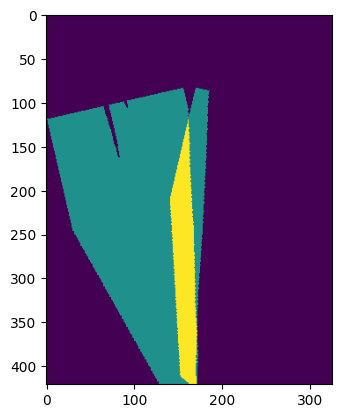

In [256]:
plt.imshow(tensor_hwn[:, :, 120])

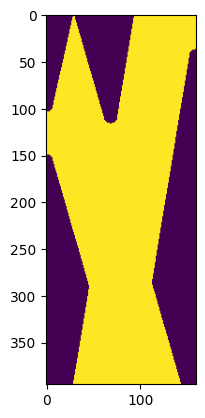

In [265]:
plt.imshow(mask_tensor1[:, :, 10])

In [18]:
import numpy as np
import cv2

def make_rotating_rect_tensor(
    H=236, W=330, n=12, *,
    length=120,
    thickness=12
) -> np.ndarray:
    """
    Create a tensor of shape (H, W, n) with one filled rectangle per slice.
    The rectangle is anchored at the bottom-center and rotates from left to right.
    """
    assert n >= 2, "Need at least two layers to interpolate angles."
    T = np.zeros((H, W, n), dtype=np.uint8)

    x0, y0 = W // 2, H - 1  # Anchor at bottom-center

    for i in range(n):
        theta_deg = 180.0 - i * (180.0 / (n - 1))  # from 180° to 0°
        theta = np.deg2rad(theta_deg)

        # direction vector
        dx = np.cos(theta)
        dy = -np.sin(theta)  # image coords: y down → invert sin

        x1 = x0 + length * dx
        y1 = y0 + length * dy

        # normal vector for thickness
        nx = -dy
        ny = dx

        half_t = thickness / 2.0

        p0 = np.array([x0, y0], dtype=np.float32)
        p1 = np.array([x1, y1], dtype=np.float32)
        nvec = np.array([nx, ny], dtype=np.float32)

        polygon = np.stack([
            p0 + nvec * half_t,
            p0 - nvec * half_t,
            p1 - nvec * half_t,
            p1 + nvec * half_t
        ]).astype(np.int32)

        canvas = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(canvas, [polygon], 1)
        T[:, :, i] = canvas

    return T

    
tensor = make_rotating_rect_tensor(H=236, W=330, n= 40, length=130, thickness=10)

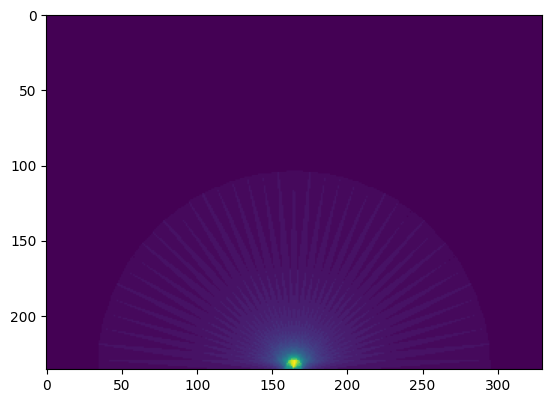

In [19]:
plt.imshow(tensor.sum(2))

In [24]:
mask_tensor1 = 0

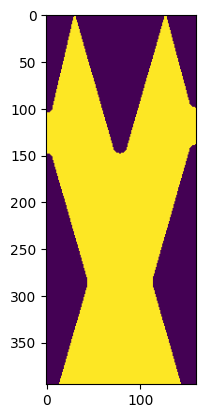

In [50]:
plt.imshow(mask_tensor1[:, :, 100])

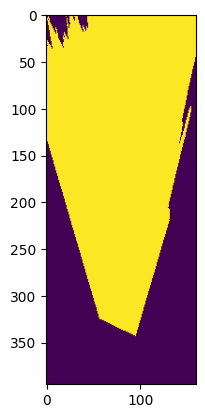

In [49]:
plt.imshow(bev_tensor1[:, :, 100])

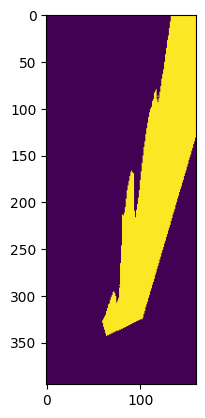

In [52]:
plt.imshow(np.fliplr(bev_tensor2[:, :, 100]))

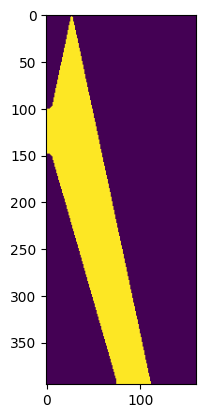

In [51]:
plt.imshow(mask_tensor2[:, :, 100])

In [736]:
import numpy as np
import cv2

import numpy as np
import cv2

def rotate_shift_sum(img1, img2, angle_deg=10.0, hor_shift_px=10):
    """
    Rotate img1 by +angle and shift LEFT, rotate img2 by -angle and shift RIGHT.
    Sum the two results on the smallest canvas that fits both, using 0-padding.

    Returns:
        output: np.ndarray of dtype float32 or uint8 (based on input),
                shape (H_out, W_out, C) or (H_out, W_out)
    """
    assert img1.shape == img2.shape, "Both images must be same size"
    H, W = img1.shape[:2]
    is_color = img1.ndim == 3
    C = img1.shape[2] if is_color else 1

    # Convert to float32 for accumulation
    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)

    # Rotation matrices around center
    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    # Horizontal shift: img1 left, img2 right
    M1[0, 2] -= hor_shift_px
    M2[0, 2] += hor_shift_px

    # Compute canvas size
    def transform_corners(M):
        corners = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        corners_h = np.hstack([corners, ones])
        transformed = (M @ corners_h.T).T
        return transformed

    corners1 = transform_corners(M1)
    corners2 = transform_corners(M2)
    all_corners = np.vstack([corners1, corners2])

    min_xy = np.floor(all_corners.min(axis=0)).astype(int)
    max_xy = np.ceil(all_corners.max(axis=0)).astype(int)
    out_W, out_H = (max_xy - min_xy)[0], (max_xy - min_xy)[1]

    shift_x, shift_y = -min_xy[0], -min_xy[1]
    M1[:, 2] += shift_x
    M2[:, 2] += shift_x
    M1[1, 2] += shift_y
    M2[1, 2] += shift_y

    # Warp both images
    dsize = (out_W, out_H)
    border_val = 0 if not is_color else (0,) * C
    warp1 = cv2.warpAffine(img1_f, M1, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    warp2 = cv2.warpAffine(img2_f, M2, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)

    # Sum the results
    summed = warp1 + warp2

    # Return in same dtype as input (clip if needed)
    if np.issubdtype(img1.dtype, np.integer):
        summed = np.clip(summed, 0, 255).astype(img1.dtype)
    return summed

n = 150
combined_image = rotate_shift_sum(np.int8(bev_tensor2[:, :, n] / 255), np.int8(bev_tensor1[:, :, n] / 255), angle_deg = -35, hor_shift_px=-40)

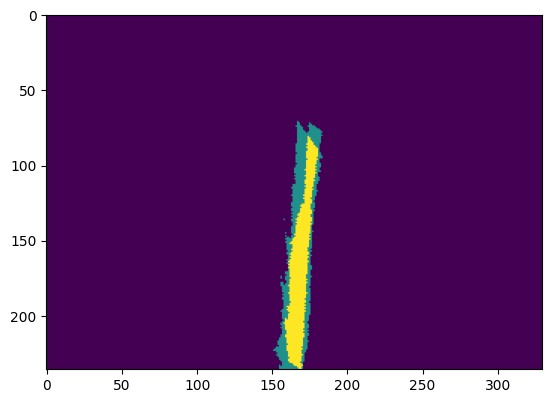

In [737]:
plt.imshow(combined_image)

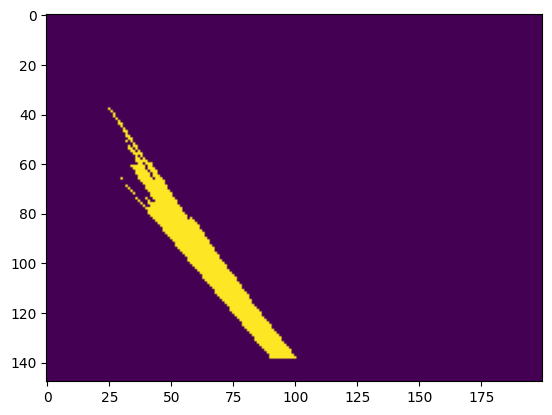

In [550]:
plt.imshow(bev_tensor2[:, :, i])

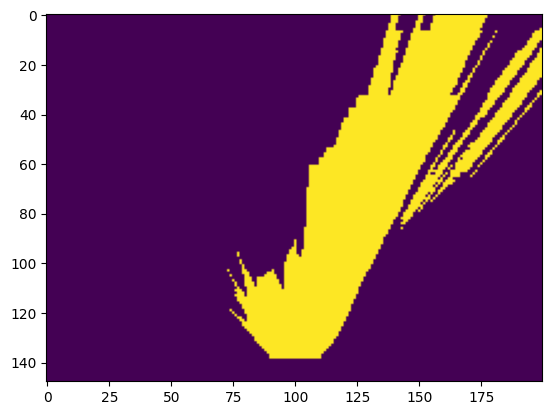

In [551]:
plt.imshow(bev_tensor1[:, :, i])

In [137]:
np.max(bev_tensor1)

255

In [289]:
bev_tensor2.shape

(395, 160, 300)

In [ ]:
assert img1.shape == img2.shape, "Both images must be same size"

In [290]:
bev_tensor1.shape

(395, 160, 300)

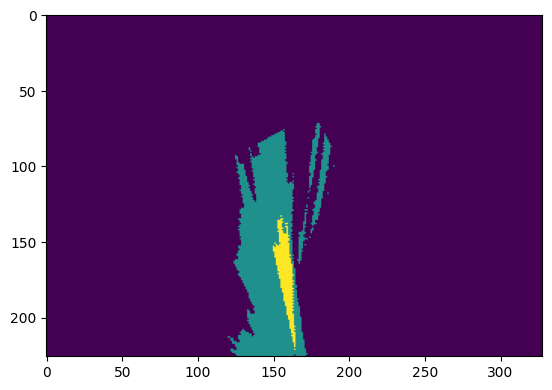

In [549]:
i = 0

plt.imshow(rotate_shift_sum(np.int8(bev_tensor2[:, :, i] / 255), np.int8(bev_tensor1[:, :, i] / 255), angle_deg = -28, hor_shift_px=-40))

In [6]:
import cv2
import numpy as np

fps = 12  # Set your desired frame rate
N = 300  # Number of frames

# Generate one combined frame to determine size
test_combined = rotate_shift_sum(bev_tensor1[:, :, 0], bev_tensor2[:, :, 0], -14, -28)
new_H, new_W = test_combined.shape[:2]

# Create the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter("/workspace/test_results/combinded_output.mp4", fourcc, fps, (new_W, new_H), isColor=False)

# Write each frame
combined_list = []
for i in range(N):
    combined = rotate_shift_sum(np.int8(bev_tensor2[:, :, i] / 255), np.int8(bev_tensor1[:, :, i] / 255), angle_deg = -35, hor_shift_px=-40)
    combined_list.append(combined)
    frame_u8 = np.clip(combined, 0, 255).astype(np.uint8)
    frame_u8 = cv2.resize(frame_u8, (new_W, new_H))  # in case sizes vary
    video_writer.write(frame_u8)

video_writer.release()


NameError: name 'rotate_shift_sum' is not defined

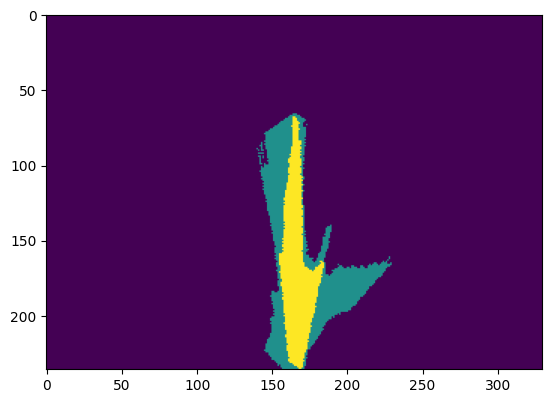

In [743]:
plt.imshow(combined_list[70])

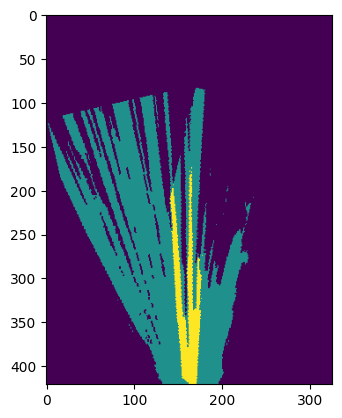

In [313]:
plt.imshow(combined_list[150])


In [316]:
import cv2
import numpy as np

import cv2
import numpy as np

def write_label_video(
    combined_list,
    out_path="combined_output.mp4",
    fps=12,
    mode="colormap",  # "scaled", "colormap", or "palette"
):
    """
    combined_list: list of 2D np.ndarray (values in {0,1,2})
    mode:
      - "scaled": map 0/1/2 -> 0/127/255 (grayscale, brighter)
      - "colormap": upscale to 0/127/255 and apply OpenCV colormap (color)
      - "palette": map labels to custom BGR colors you choose
    """
    assert len(combined_list) > 0, "combined_list is empty."
    H, W = combined_list[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    if mode == "scaled":
        # single-channel grayscale but bright enough to see
        vw = cv2.VideoWriter(out_path, fourcc, fps, (W, H), isColor=False)
        if not vw.isOpened():
            raise RuntimeError("Failed to open VideoWriter.")
        lut = np.array([0, 127, 255], dtype=np.uint8)
        for frame in combined_list:
            f = frame.astype(np.uint8, copy=False)
            out = lut[f]  # 0/127/255
            vw.write(out)
        vw.release()
        return

    # color modes -> write 3-channel BGR
    vw = cv2.VideoWriter(out_path, fourcc, fps, (W, H), isColor=True)
    if not vw.isOpened():
        raise RuntimeError("Failed to open VideoWriter.")

    if mode == "colormap":
        # Map to 0/127/255, then apply a perceptual colormap
        lut = np.array([0, 127, 255], dtype=np.uint8)
        for frame in combined_list:
            f = lut[frame.astype(np.uint8, copy=False)]
            colored = cv2.applyColorMap(f, cv2.COLORMAP_TURBO)  # or COLORMAP_JET
            vw.write(colored)

    elif mode == "palette":
        # Pick explicit colors for labels (B,G,R)
        # e.g., 0=black, 1=blue, 2=yellow
        palette = np.array([
            [0, 0, 0],        # label 0 -> black
            [255, 0, 0],      # label 1 -> blue (BGR)
            [0, 255, 255],    # label 2 -> yellow (BGR)
        ], dtype=np.uint8)

        for frame in combined_list:
            f = frame.astype(np.uint8, copy=False)
            out = palette[f]  # shape (H,W,3)
            vw.write(out)

    else:
        raise ValueError("mode must be 'scaled', 'colormap', or 'palette'.")

    vw.release()

write_label_video(combined_list, "/workspace/test_results/combined_road_detection.mp4", fps=15)


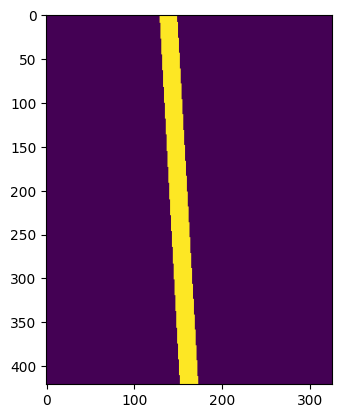

In [319]:
plt.imshow(mask_tensor1[:, :, 20])

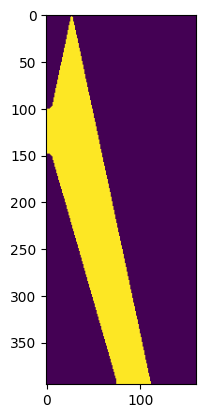

In [59]:
plt.imshow(mask_tensor2[:, :, 100])

In [58]:
from __future__ import annotations
import numpy as np
import cv2
from dataclasses import dataclass

# =========================
# Classes (with alignment fix)
# =========================

@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S


class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg  # expose for debugging

        S = grid.scaling_matrix()
        self.S = S        # expose for debugging

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M        # expose for debugging

        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)

        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)

        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)

        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src


# =========================
# Usage + Debugging
# =========================

# --- Input mask (binary 0/1, uint8 or bool). Replace this with your real mask. ---
# Example synthetic to keep script runnable if needed:
H, W = 540, 960
mask = np.zeros((H, W), dtype=np.uint8)
top_y, bot_y = int(H*0.45), int(H*0.98)
top_w, bot_w = int(W*0.20), int(W*0.90)
cx = W//2
src_quad = np.array([
    [cx - top_w//2, top_y],      # TL
    [cx + top_w//2, top_y],      # TR
    [cx + bot_w//2, bot_y],      # BR
    [cx - bot_w//2, bot_y],      # BL
], dtype=np.int32)
cv2.fillPoly(mask, [src_quad], 1)

# --- Intrinsics K ---
# If you have calibrated K0 at (W0, H0), scale it; otherwise use synthetic K for (W, H).
cx0, cy0 = W/2.0, H/2.0
fx = fy = 1100.0
K = np.array([[fx, 0,   cx0],
              [0,  fy,  cy0],
              [0,  0,   1.0]], dtype=np.float64)

# --- Pose (keep sign consistent: negative pitch = tilt down with this alignment) ---
h = 1.4
pitch_rad = -np.deg2rad(6.0)  # downward tilt (keep this sign everywhere)
proj_cal = BEVProjector().set_intrinsics(K).set_pose(
    height_m=h,
    roll=0.0,
    pitch=pitch_rad,   # <-- FIX: do NOT negate again
    yaw=0.0
)

# --- Horizon and BEV grid (keep far edge below horizon) ---
y_horizon = h / np.tan(abs(pitch_rad))  # meters
grid = BEVGrid(
    meters_per_pixel=0.10,                         # 10 cm/px
    forward_range_m=(0.5, min(6.0, 0.9*y_horizon)),
    lateral_range_m=(-3.0, 3.0)
)

# --- Warp to BEV ---
bev_cal = proj_cal.warp_calibrated(mask01=mask, grid=grid)

# =========================
# Debug prints
# =========================

np.set_printoptions(precision=6, suppress=True)

print("\n=== DEBUG: Intrinsics K ===\n", K)
print("\n=== DEBUG: Pose (deg) ===")
print(" roll=", np.rad2deg(proj_cal.roll), " pitch=", np.rad2deg(proj_cal.pitch), " yaw=", np.rad2deg(proj_cal.yaw))
print(" height_m=", proj_cal.height_m)
print(" y_horizon(m)=", y_horizon)

print("\n=== DEBUG: H_pg (ground->image) ===\n", proj_cal.H_pg)
print("\n=== DEBUG: S (dst-px -> ground-m) ===\n", proj_cal.S)
print("\n=== DEBUG: M (src->dst, used by warpPerspective) ===\n", proj_cal.M)

# Project BEV rectangle corners into the image to verify coverage
H_pg, S = proj_cal.H_pg, grid.scaling_matrix()
A = H_pg @ S
W_out, H_out = grid.size
dst_corners = np.array([[0,0,1],
                        [W_out-1,0,1],
                        [W_out-1,H_out-1,1],
                        [0,H_out-1,1]], dtype=np.float64).T
img_corners_h = A @ dst_corners
img_corners = (img_corners_h[:2] / img_corners_h[2]).T  # Nx2
print("\n=== DEBUG: BEV corners -> image (u,v) ===\n", img_corners)

# Coverage ratio: fraction of BEV pixels that sample inside the source image
# (Warp an all-ones source through the same mapping to see what's valid.)
ones_src = np.ones((H, W), dtype=np.uint8) * 255
valid = cv2.warpPerspective(
    ones_src, np.linalg.inv(A), (W_out, H_out),
    flags=cv2.INTER_NEAREST, borderValue=0
)
coverage_ratio = valid.sum() / 255.0 / (W_out * H_out)
print("\n=== DEBUG: coverage_ratio ===\n", coverage_ratio)

print("\n=== DEBUG: bev_cal.sum() ===\n", bev_cal.sum())

# Optional: save for inspection
# cv2.imwrite("input_mask.png", mask * 255)
# cv2.imwrite("bev_cal.png", bev_cal)
# cv2.imwrite("valid_coverage.png", valid)



=== DEBUG: Intrinsics K ===
 [[1100.    0.  480.]
 [   0. 1100.  270.]
 [   0.    0.    1.]]

=== DEBUG: Pose (deg) ===
 roll= 0.0  pitch= -6.000000000000001  yaw= 0.0
 height_m= 1.4
 y_horizon(m)= 13.320110235911617

=== DEBUG: H_pg (ground->image) ===
 [[1093.974085  480.        160.973833]
 [-114.98131   270.       1531.563719]
 [   0.          1.          0.      ]]

=== DEBUG: S (dst-px -> ground-m) ===
 [[ 0.1  0.  -3. ]
 [ 0.  -0.1  6. ]
 [ 0.   0.   1. ]]

=== DEBUG: M (src->dst, used by warpPerspective) ===
 [[  0.011077   0.018424 -10.291498]
 [  0.004073   0.038748 -22.416672]
 [  0.000068   0.000646  -0.206945]]

=== DEBUG: BEV corners -> image (u,v) ===
 [[  -40.15807    582.751275]
 [ 1035.583113   469.68632 ]
 [ 6035.831133  2266.863202]
 [-4721.580702  3397.512746]]

=== DEBUG: coverage_ratio ===
 0.06181818181818182

=== DEBUG: bev_cal.sum() ===
 28305


In [47]:
H, W = mask.shape[:2]
# Image corners for reference
img_poly = np.array([[0,0],[W-1,0],[W-1,H-1],[0,H-1]], dtype=np.float64)

# Map BEV rectangle corners -> image using current H_pg and S
H_pg = proj.H_pg          # after set_intrinsics/set_pose
S    = proj.S             # from your grid
A    = H_pg @ S           # i ~ A * d  (d = BEV pixel homogeneous)

bev_W, bev_H = grid.size
dst_corners = np.array([[0,0,1],
                        [bev_W-1,0,1],
                        [bev_W-1,bev_H-1,1],
                        [0,bev_H-1,1]], dtype=np.float64).T
img_corners_h = A @ dst_corners
img_corners   = (img_corners_h[:2] / img_corners_h[2]).T  # Nx2

print("Projected BEV corners into image:\n", img_corners)
# If all points are far outside [0..W)x[0..H), warp will paint only zeros.


Projected BEV corners into image:
 [[   199.00516625    402.76593048]
 [   775.16485097    342.20910743]
 [ 44754.72764562  11101.36611449]
 [-41669.22506188  20184.88957245]]


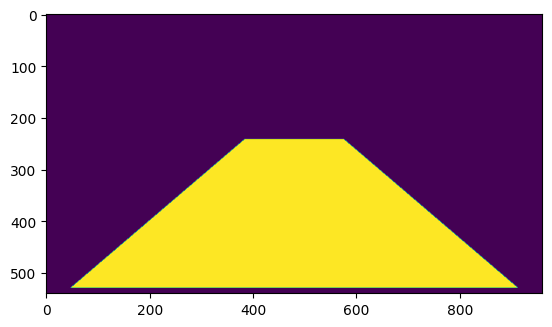

In [56]:
plt.imshow(mask)

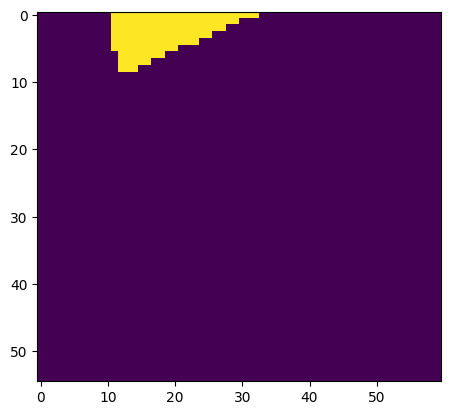

In [57]:
plt.imshow(bev_cal)

In [41]:
bev_cal.sum()

0

In [35]:
mask.sum()

151873

In [14]:
proj_calib

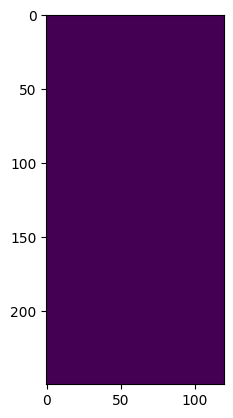

In [15]:
plt.imshow(bev_cal)

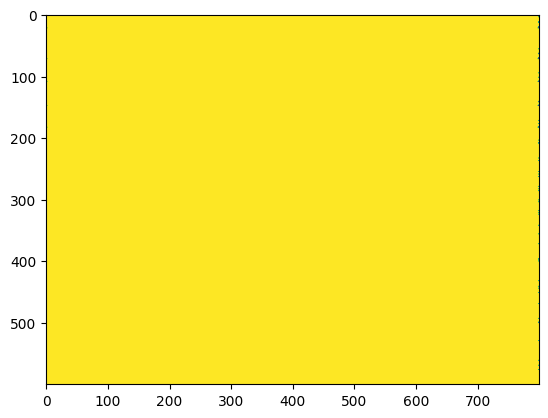

In [61]:
plt.imshow(bev_trap)

In [55]:
mask01 = mask

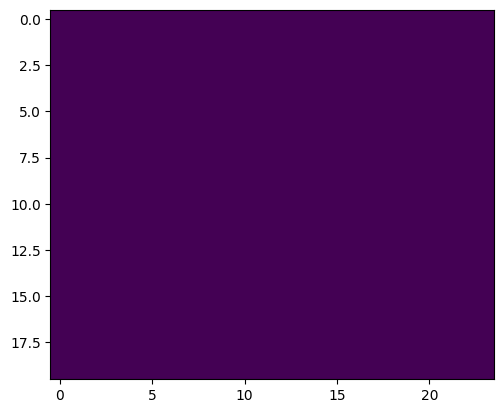

In [59]:
plt.imshow(bev)

In [39]:
np.bincount(segmened_video[299].ravel())

array([116071,   6692,  33745,      0,   2491,   1562,      0,    894,
       104428,    257,  25401,   1613,      0,  13388,      0,      0,
            0,     17,    641])

In [40]:
gray_tensor.shape

(300, 480, 640)

In [129]:
video_tensor[250][400:, :100].shape

(80, 100, 3)

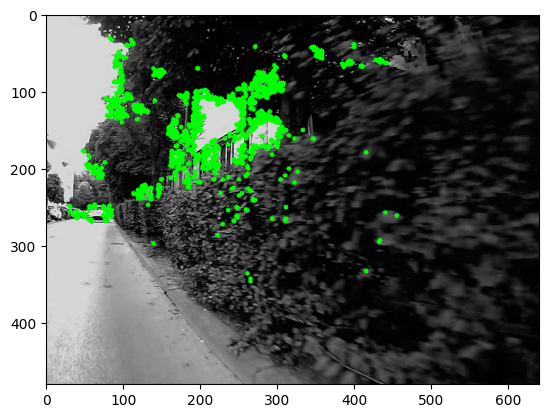

In [211]:
import cv2, numpy as np

def to_gray_u8(img):
    if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        img = (np.clip(img,0,1)*255).astype(np.uint8) if img.max()<=1.0 else np.clip(img,0,255).astype(np.uint8)
    return img

def to_bgr_u8(img):
    if img.ndim == 2: img = cv2.cvtColor(to_gray_u8(img), cv2.COLOR_GRAY2BGR)
    if img.dtype != np.uint8:
        img = (np.clip(img,0,1)*255).astype(np.uint8) if img.max()<=1.0 else np.clip(img,0,255).astype(np.uint8)
    return img

def draw_orb_points(img, nfeatures=1500, mask=None, max_draw=None):
    """Detect ORB features and draw them as points (no matches)."""
    g = to_gray_u8(img)
    orb = cv2.ORB_create(nfeatures=nfeatures)
    kps = orb.detect(g, mask)
    if not kps: 
        return to_bgr_u8(img)
    # optionally keep top-N by response
    if max_draw is not None and len(kps) > max_draw:
        kps = sorted(kps, key=lambda k:k.response, reverse=True)[:max_draw]
    vis = to_bgr_u8(img).copy()
    for kp in kps:
        x,y = map(int, kp.pt)
        cv2.circle(vis, (x,y), 3, (0,255,0), -1)
    return vis

n = 52


gray_frame_last = gray_tensor[n]


# g: HxW uint8 grayscale (what ORB expects)
g = to_gray_u8(gray_frame_last)  # ensures single channel uint8
h, w = g.shape

# Build a proper mask from your segmented labels
m = (segmened_video[n] != 13)    # boolean mask (True = keep)
if m.ndim == 3:
    # If segmentation is HxWxC, collapse channels (keep any non-13 across channels)
    m = np.any(m, axis=-1)

# Cast to uint8 0/255
m = m.astype(np.uint8) * 255

# Zero out the top 300 rows (cap to image height to be safe)
m[:min(300, h), :] = 0

# Ensure mask size matches the image; if not, resize with NEAREST (keeps 0/255)
if m.shape != (h, w):
    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

# Make sure it’s contiguous and single-channel
m = np.ascontiguousarray(m)

# Now detect
vis = draw_orb_points(g, max_draw=1500)  # g is fine (uint8), m is uint8 0/255

plt.imshow(vis)





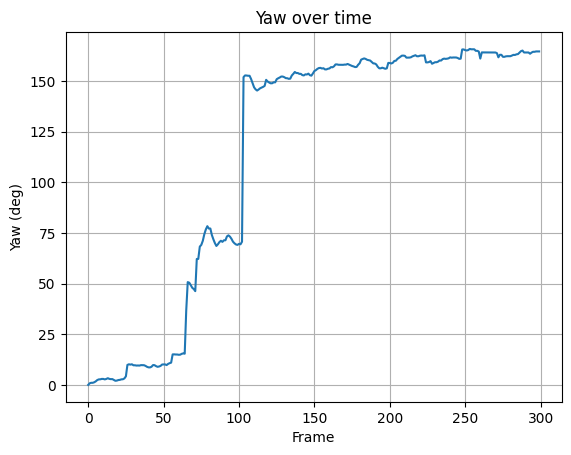

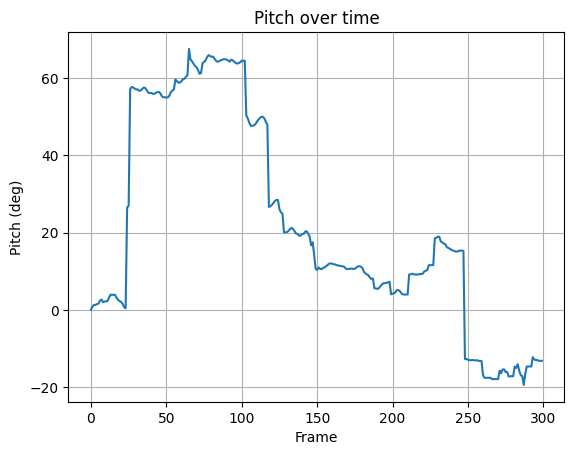

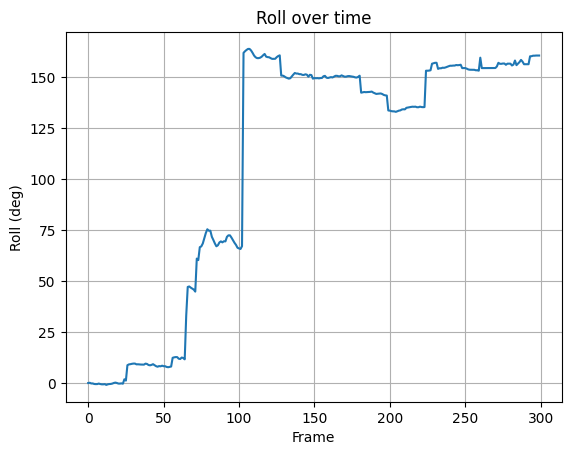

Frames processed: 300; accepted (inliers >= 60): 106


In [213]:
# --- Robust camera orientation tracker + plots (single cell) ---
import cv2, numpy as np
from math import atan2, asin, tan, radians, degrees
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------
def to_gray_u8(img):
    """Return a single-channel uint8 grayscale image."""
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        mx = float(img.max()) if img.size else 1.0
        if mx <= 1.0:
            img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        else:
            img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def build_mask(seg_frame, h, w, ignore_label=13, top_cut=300):
    """
    Make a uint8 (0/255) mask where 255 means 'use for features'.
    - Ignores pixels with label == ignore_label
    - Zeros out top 'top_cut' rows
    """
    # Accept HxW or HxWxC segmentation; keep any non-ignore label across channels
    m = (seg_frame != ignore_label)
    if m.ndim == 3:
        m = np.any(m, axis=-1)
    m = m.astype(np.uint8) * 255

    if m.shape != (h, w):
        if m.size == 0:
            m = np.zeros((h, w), np.uint8)
        else:
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

    m[:min(top_cut, h), :] = 0  # zero out the top band
    return np.ascontiguousarray(m)

def euler_zyx_from_R(R):
    """
    Convert rotation matrix to ZYX (yaw, pitch, roll), radians.
    R = Rz(yaw) * Ry(pitch) * Rx(roll)
    """
    sy = -R[2, 0]
    sy = float(np.clip(sy, -1.0, 1.0))  # guard for numeric drift
    pitch = asin(sy)
    roll  = atan2(R[2, 1], R[2, 2])
    yaw   = atan2(R[1, 0], R[0, 0])
    return yaw, pitch, roll

def intrinsics_from_fov(h, w, fov_deg=60.0):
    """Simple pinhole intrinsics assuming centered principal point and square pixels."""
    f = 0.5 * w / tan(radians(fov_deg * 0.5))
    K = np.array([[f, 0, w/2.0],
                  [0, f, h/2.0],
                  [0, 0, 1.0]], dtype=np.float64)
    return K

    
# 1) Replace preprocess_frame with this version
def preprocess_frame(img):
    """Grayscale uint8 -> light denoise -> CLAHE -> mild sharpen."""
    g = to_gray_u8(img)  # <-- ensure single-channel uint8 first
    g = cv2.GaussianBlur(g, (3, 3), sigmaX=0.8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(g)
    sharp = cv2.GaussianBlur(g, (0, 0), sigmaX=1.0)
    g = cv2.addWeighted(g, 1.5, sharp, -0.5, 0)
    return g


# ---------------------------------------------------------------
# Core tracker (keeps only most reliable matches)
# ---------------------------------------------------------------
def track_orientation(
    gray_tensor, segmened_video,
    ignore_label=13, top_cut=300,
    nfeatures=2500, ratio_thresh=0.75,
    keep_best_N=100,                   # <-- keep only top-N matches by distance
    min_inliers=30,                    # <-- require at least this many inliers to accept a step
    ransac_thresh=1.0, ransac_prob=0.999,
    K=None, fov_deg=60.0,
    smooth_alpha=None                  # e.g., 0.2 for light EMA smoothing of angles
):
    """
    Compute cumulative camera orientation (yaw/pitch/roll in degrees) per frame
    using ORB + robust matching + Essential matrix + recoverPose.

    Returns: list of dict (frame, yaw_deg, pitch_deg, roll_deg, inliers, matches_used)
    """
    N = len(gray_tensor)
    if N < 2:
        return [{"frame": 0, "yaw_deg": 0.0, "pitch_deg": 0.0, "roll_deg": 0.0,
                 "inliers": 0, "matches_used": 0}]

    # ORB + matcher
    orb = cv2.ORB_create(nfeatures=nfeatures)
    bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    # Frame 0 preprocess
    g0 = preprocess_frame(gray_tensor[0])   # (instead of mixing manual grayscale + preprocess)
    h, w = g0.shape    
    if K is None:
        K = intrinsics_from_fov(h, w, fov_deg=fov_deg)

    m0 = build_mask(segmened_video[0], h, w, ignore_label, top_cut)
    kp0, des0 = orb.detectAndCompute(g0, mask=m0)

    R_cum = np.eye(3, dtype=np.float64)  # accumulate rotation
    out = [{
        "frame": 0, "yaw_deg": 0.0, "pitch_deg": 0.0, "roll_deg": 0.0,
        "inliers": 0, "matches_used": 0
    }]

    # optional EMA init
    if smooth_alpha is not None:
        yaw_s, pitch_s, roll_s = 0.0, 0.0, 0.0

    for i in range(1, N):
        g1 = preprocess_frame(gray_tensor[i])     # preprocess here too
        if g1.shape != (h, w):
            g1 = cv2.resize(g1, (w, h), interpolation=cv2.INTER_AREA)
    
        m1 = build_mask(segmened_video[i], h, w, ignore_label, top_cut)
        kp1, des1 = orb.detectAndCompute(g1, mask=m1)
        
        # if insufficient features, carry forward orientation
        if des0 is None or des1 is None or len(kp0) < 8 or len(kp1) < 8:
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": 0, "matches_used": 0})
            kp0, des0 = kp1, des1
            continue

        # KNN match + Lowe ratio
        knn = bf.knnMatch(des0, des1, k=2)
        good = []
        for pair in knn:
            if len(pair) == 2:
                a, b = pair
                if a.distance < ratio_thresh * b.distance:
                    good.append(a)

        # Keep only top-N most reliable matches by descriptor distance
        if len(good) > 0:
            good = sorted(good, key=lambda m: m.distance)[:keep_best_N]

        if len(good) < 8:
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": 0, "matches_used": len(good)})
            kp0, des0 = kp1, des1
            continue

        pts0 = np.float32([kp0[m.queryIdx].pt for m in good])
        pts1 = np.float32([kp1[m.trainIdx].pt for m in good])

        # Essential matrix with RANSAC
        E, inliers_E = cv2.findEssentialMat(
            pts0, pts1, K,
            method=cv2.RANSAC, prob=ransac_prob, threshold=ransac_thresh
        )

        if E is None or inliers_E is None or int(np.sum(inliers_E)) < min_inliers:
            # Not reliable enough → keep previous orientation
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": int(np.sum(inliers_E)) if inliers_E is not None else 0,
                        "matches_used": len(good)})
            kp0, des0 = kp1, des1
            continue

        # Recover pose using only inliers_E
        inliers_count, R_step, t, inliers_pose = cv2.recoverPose(
            E, pts0, pts1, K, mask=inliers_E
        )

        # Enforce reliability again
        used_inliers = int(inliers_count) if isinstance(inliers_count, (int, np.integer)) else int(np.sum(inliers_pose))
        if used_inliers < min_inliers:
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": used_inliers, "matches_used": len(good)})
            kp0, des0 = kp1, des1
            continue

        # Accumulate rotation
        R_cum = R_step @ R_cum
        yaw, pitch, roll = euler_zyx_from_R(R_cum)
        yd, pd, rd = map(degrees, (yaw, pitch, roll))

        if smooth_alpha is not None:
            yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
            pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
            roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
            yd, pd, rd = yaw_s, pitch_s, roll_s

        out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                    "inliers": used_inliers, "matches_used": len(good)})

        # advance
        kp0, des0 = kp1, des1

    return out

# ---------------------------------------------------------------
# Run on your tensors and plot each axis
# ---------------------------------------------------------------
# Expect you already have: gray_tensor, segmened_video
# Example call (tweak params as needed):
orientations = track_orientation(
    gray_tensor, segmened_video,
    ignore_label=200, top_cut=0,
    nfeatures=2500,
    ratio_thresh=0.75,
    keep_best_N=100,
    min_inliers=30,
    ransac_thresh=1.0, ransac_prob=0.999,
    K=None,          # or pass your real camera matrix here
    fov_deg=60.0,
    smooth_alpha=None  # e.g., 0.2 for light smoothing
)

df = pd.DataFrame(orientations)

# Optionally keep only frames with reliable inliers for plotting
df_plot = df[df["inliers"] >= 0].copy()
if df_plot.empty:
    df_plot = df.copy()

# --- Plot each axis (separate figures) ---
plt.figure()
plt.plot(df_plot["frame"], df_plot["yaw_deg"])
plt.xlabel("Frame"); plt.ylabel("Yaw (deg)"); plt.title("Yaw over time"); plt.grid(True)

plt.figure()
plt.plot(df_plot["frame"], df_plot["pitch_deg"])
plt.xlabel("Frame"); plt.ylabel("Pitch (deg)"); plt.title("Pitch over time"); plt.grid(True)

plt.figure()
plt.plot(df_plot["frame"], df_plot["roll_deg"])
plt.xlabel("Frame"); plt.ylabel("Roll (deg)"); plt.title("Roll over time"); plt.grid(True)

plt.show()

# Quick textual summary
print(f"Frames processed: {len(df)}; accepted (inliers >= 60): {int((df['inliers']>=60).sum())}")


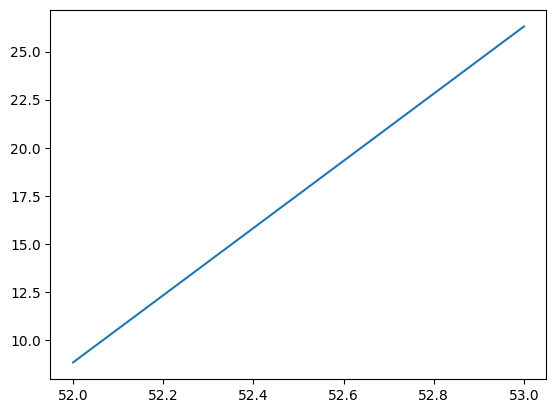

In [197]:
plt.plot(df_plot["roll_deg"][52:54])

In [198]:
52

gray_frame_last = gray_tensor[i]
gray_frame      = gray_tensor[i+1]

# relative rotation from frame i -> i+1
R_step = estimate_rotation_R(gray_frame_last, gray_frame, K)

In [199]:
R

array([[ 0.99972338,  0.02175708,  0.0089325 ],
       [-0.02136903,  0.99891189, -0.04145369],
       [-0.00982469,  0.04125134,  0.9991005 ]])

In [157]:
orientations
import pandas as pd

In [158]:
df = pd.DataFrame(orientations)

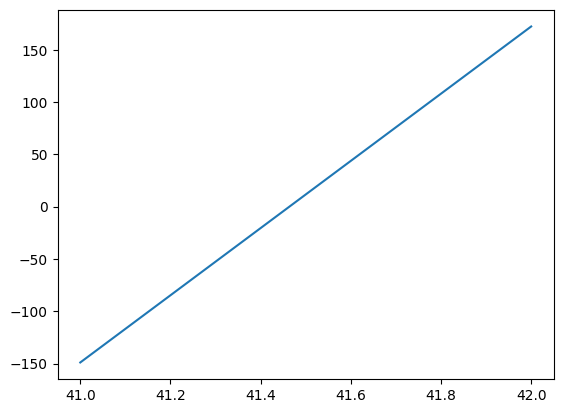

In [167]:
df = pd.DataFrame(orientations)
df_filtered = df[df["inliers"] >= 30]  # keep only frames with reliable orientation

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_filtered["frame"], df_filtered["yaw_deg"], label="Yaw")
plt.plot(df_filtered["frame"], df_filtered["pitch_deg"], label="Pitch")
plt.plot(df_filtered["frame"], df_filtered["roll_deg"], label="Roll")
plt.xlabel("Frame")
plt.ylabel("Degrees")
plt.title("Filtered Camera Orientation Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
plt.imshow

In [44]:
target_color = np.array([0.87058824, 0.85490197, 0.39215687], dtype=np.float32)

# Compute a mask where each pixel exactly matches the target color
mask = np.all(video_tensor == target_color, axis=-1)  # shape: (N, H, W)

# Expand mask to shape (N, H, W, 1) for broadcasting
  # or 1e-3
tol = 1e-1
mask = np.all(np.abs(video_tensor - target_color) < tol, axis=-1)
mask = mask[..., np.newaxis]
filtered_video = video_tensor * mask# Zero out non-matching pixels


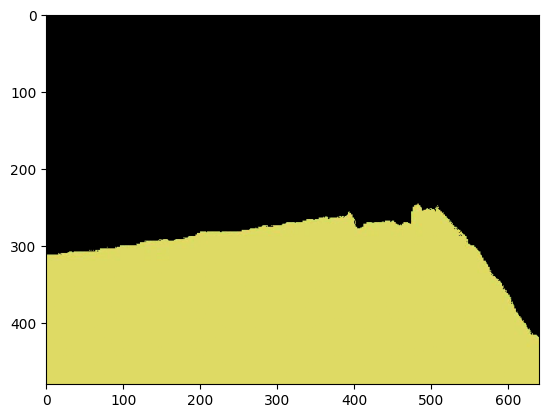

In [45]:
plt.imshow(filtered_video[100])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3941176].


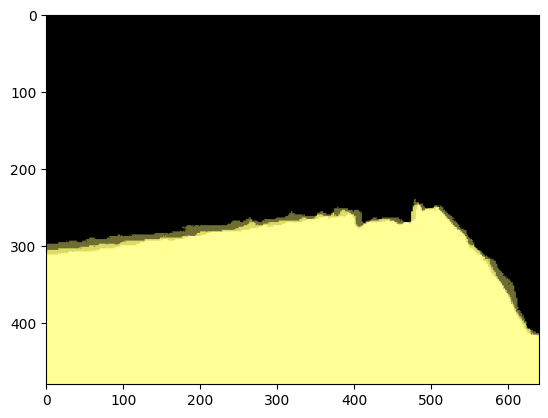

In [50]:
plt.imshow((filtered_video[100] + filtered_video[101] + filtered_video[101]) / 2)

In [51]:
import numpy as np

def geometric_average(tensor: np.ndarray, n: int, lambda_: float) -> np.ndarray:
    """
    Geometric (exponentially) weighted average over the last up to n frames in `tensor`.
    `tensor` is shaped (T, ...), ordered oldest -> newest. Returns a single frame (...).

    Weights ~ lambda_^k with k decreasing toward the newest frame, i.e. newest gets weight 1.
    For lambda_ = 0 -> newest only; lambda_ = 1 -> uniform over the window.
    """
    if tensor.ndim < 1 or tensor.shape[0] == 0:
        raise ValueError("`tensor` must have shape (T, ...) with T >= 1")
    if n <= 0:
        raise ValueError("`n` must be > 0")
    # clamp lambda_ to [0, 1]
    lambda_ = float(max(0.0, min(1.0, lambda_)))

    T = tensor.shape[0]
    m = min(int(n), T)
    window = tensor[-m:]

    # weights for [oldest ... newest] = [lambda_^(m-1), ..., lambda_^1, lambda_^0]
    exps = np.arange(m - 1, -1, -1, dtype=np.float64)
    w = np.power(lambda_, exps)
    w /= w.sum()

    # compute weighted average in float for precision
    work_dtype = np.float32 if tensor.dtype.kind != 'f' else tensor.dtype
    window_f = window.astype(work_dtype, copy=False)
    out = np.tensordot(w, window_f, axes=(0, 0))  # shape (...,)

    # cast back to input dtype if needed (round for integers)
    if tensor.dtype != out.dtype:
        if np.issubdtype(tensor.dtype, np.integer):
            out = np.rint(out).astype(tensor.dtype, copy=False)
        else:
            out = out.astype(tensor.dtype, copy=False)
    return out


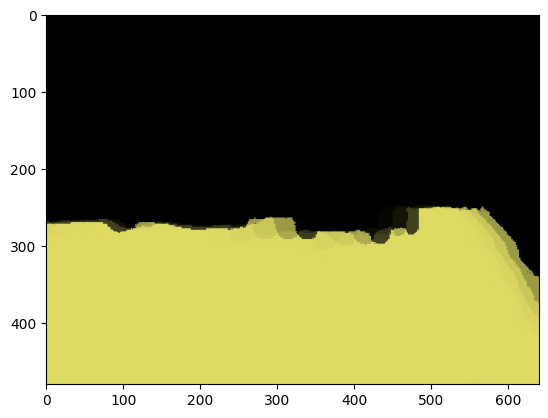

In [64]:
n = 30

plt.imshow(geometric_average(filtered_video[n:n+50], 5, 0.3))

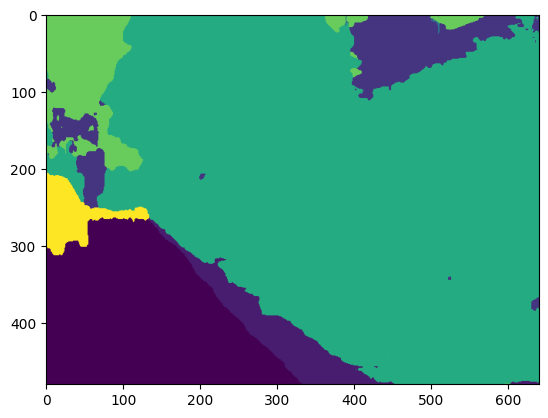

In [111]:
plt.imshow(segmened_video[80])

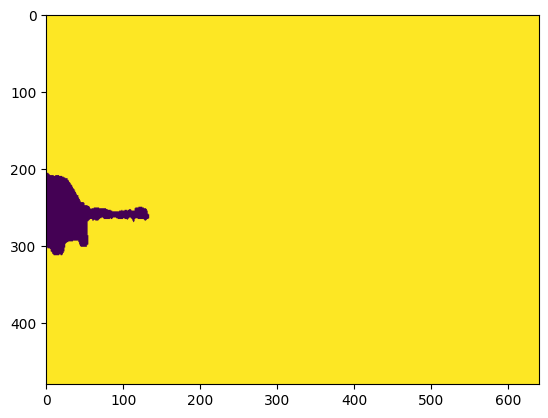

In [118]:
plt.imshow(np.not_equal(segmened_video[80], 13))

In [112]:
values, counts = np.unique(segmened_video[80], return_counts=True)

# Print results
for val, count in zip(values, counts):
    print(f"Class {val}: {count} pixels")

Class 0: 47381 pixels
Class 1: 10491 pixels
Class 2: 17511 pixels
Class 5: 77 pixels
Class 8: 209475 pixels
Class 9: 9 pixels
Class 10: 16796 pixels
Class 13: 5460 pixels


In [41]:
mask.shape

(300, 480, 640)

In [3]:
import random

In [206]:
total_balance 

4457619.4495829195

In [138]:
total_balance 

68502293.82850145

In [62]:
n = 0
for i in range(10000):
    n += biased_coin_flip(0.8)

In [63]:
n

8051

In [20]:
random.random() < 0.5

True